In [2]:
import subprocess, sys
for lib in ['pandas','numpy','matplotlib','seaborn','scipy','scikit-learn','missingno','openpyxl']:
    subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'])
print('Libraries ready ✓')

Libraries ready ✓


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
from scipy.stats import wilcoxon, pearsonr, spearmanr, kruskal, mannwhitneyu
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality style ─────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f7f7f7',
    'axes.edgecolor'   : '#cccccc',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : '#e0e0e0',
    'grid.linewidth'   : 0.6,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 16, # Increased from 11
    'axes.titlesize'   : 16, # Increased from 13
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 16, # Increased from 11
    'legend.fontsize'  : 16, # Increased from 9
    'xtick.labelsize'  : 16, # Increased from 9
    'ytick.labelsize'  : 16, # Increased from 9
    'legend.framealpha': 0.9,
    'legend.edgecolor' : '#cccccc',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'Liberation Sans', 'sans-serif'],
    'font.monospace': ['DejaVu Sans Mono', 'monospace'],
})

# Colour palette ─ accessible, print-friendly
C1 = '#2c7bb6'   # blue
C2 = '#d7191c'   # red
C3 = '#1a9641'   # green
C4 = '#fdae61'   # amber
C5 = '#7b2d8b'   # purple
GREY = '#888888'
CAT_PAL = [C1, C2, C3, C4, C5, '#4dac26', '#b8860b', '#008080', '#c2561e', '#5e5e5e']

def save(name):
    plt.savefig(f'{name}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{name}.pdf', bbox_inches='tight')          # vector for LaTeX
    print(f'  Saved → {name}.png / .pdf')

print('Setup complete ✓')

Setup complete ✓


---
## 1. Load Dataset

In [4]:

# ─────────────────────────────────────────────────────────────────────────────
# §1  LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = 'fraud_data_FINAL_FIXED (1).xlsx'

if DATA_PATH.endswith('.csv'):
    df = pd.read_csv(DATA_PATH, low_memory=False)
else:
    df = pd.read_excel(DATA_PATH)

# ── Coerce numeric columns ────────────────────────────────────────────────────
for col in ['Amount_Loss', 'POH', 'Age', 'LLM_Predicted_Amount', 'Final_Amount_Loss']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Convenience aliases ───────────────────────────────────────────────────────
df['_reported'] = df['Amount_Loss']
df['_final']    = df['Final_Amount_Loss']
df['_llm']      = df['LLM_Predicted_Amount']
df['_poh']      = df['POH'].fillna(0)      # NaN → ₹0 (no POH held)
df['has_POH']   = df['_poh'] > 0

# ── Data integrity note — extreme outlier in Final_Amount_Loss ────────────────
# Final_Amount_Loss max = ₹10,000,000,000 (₹10B) while median = ₹67,000.
# This is 5 orders of magnitude above the median and dominates all raw-scale
# metrics (R², MAE, RMSE). We retain it in the data but report log-scale
# metrics throughout. Raw R² is NOT reported as a primary metric anywhere.
_n_extreme = (df['_final'] > 1e8).sum()
print(f'Loaded  : {DATA_PATH}')
print(f'Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns : {df.columns.tolist()}')
print(f'\nData quality note:')
print(f'  Records with Final_Amount_Loss > ₹1 Cr (potential outlier): {_n_extreme:,}')
print(f'  All financial metrics reported on log scale throughout.')


Loaded  : fraud_data_FINAL_FIXED (1).xlsx
Shape   : 19,480 rows × 23 columns
Columns : ['SI_No', 'Acknowledgement_No', 'District', 'Police_Station', 'Name_of_Victim', 'Gender', 'Minor_Head', 'Amount_Loss', 'POH', 'Age', 'Age_Group', 'Profession', 'Suspect_URL_Website', 'Suspect_Platform', 'English_Translation', 'Brief', 'LLM_Predicted_Amount', 'Final_Amount_Loss', '_reported', '_final', '_llm', '_poh', 'has_POH']

Data quality note:
  Records with Final_Amount_Loss > ₹1 Cr (potential outlier): 7
  All financial metrics reported on log scale throughout.


---
## 2. Descriptive Overview

In [5]:
N = len(df)
num_cols = ['Amount_Loss','Final_Amount_Loss','LLM_Predicted_Amount','POH','Age']

print('='*65)
print('DATASET OVERVIEW')
print('='*65)
print(f'Total complaints       : {N:,}')
print(f'Districts              : {df.District.nunique()}')
print(f'Police stations        : {df.Police_Station.nunique()}')
print(f'Crime categories       : {df.Minor_Head.nunique()}')
print(f'Platforms (non-null)   : {df.Suspect_Platform.nunique()}')
print()
print('Financial summary (₹)')
print('-'*65)
for col in ['Amount_Loss','Final_Amount_Loss','LLM_Predicted_Amount','POH']:
    s = df[col].dropna()
    print(f'  {col:<28}: n={len(s):>6,}  mean={s.mean():>12,.0f}  '
          f'median={s.median():>12,.0f}  total={s.sum():>16,.0f}')
print()
desc = df[num_cols].describe().T.round(2)
desc['missing_%'] = df[num_cols].isnull().mean().mul(100).round(2)
print('Descriptive statistics:')
print(desc.to_string())

DATASET OVERVIEW
Total complaints       : 19,480
Districts              : 30
Police stations        : 693
Crime categories       : 9
Platforms (non-null)   : 4

Financial summary (₹)
-----------------------------------------------------------------
  Amount_Loss                 : n=19,480  mean=     428,935  median=      62,000  total=   8,355,648,151
  Final_Amount_Loss           : n=19,480  mean=   1,097,756  median=      67,000  total=  21,384,283,814
  LLM_Predicted_Amount        : n= 4,764  mean=   3,173,040  median=      70,000  total=  15,116,363,978
  POH                         : n=13,404  mean=      86,221  median=      16,667  total=   1,155,703,589

Descriptive statistics:
                        count        mean           std     min       25%      50%        75%           max  missing_%
Amount_Loss           19480.0   428934.71  2.177582e+06    1.00  20100.00  62000.0  206234.00  1.480000e+08       0.00
Final_Amount_Loss     19480.0  1097755.84  7.179854e+07    1.00  216

---
## 3. DATA AVAILABILITY & COMPLETENESS
### 3.1 Field-Level Completeness Scorecard

  Saved → fig01_completeness_scorecard.png / .pdf


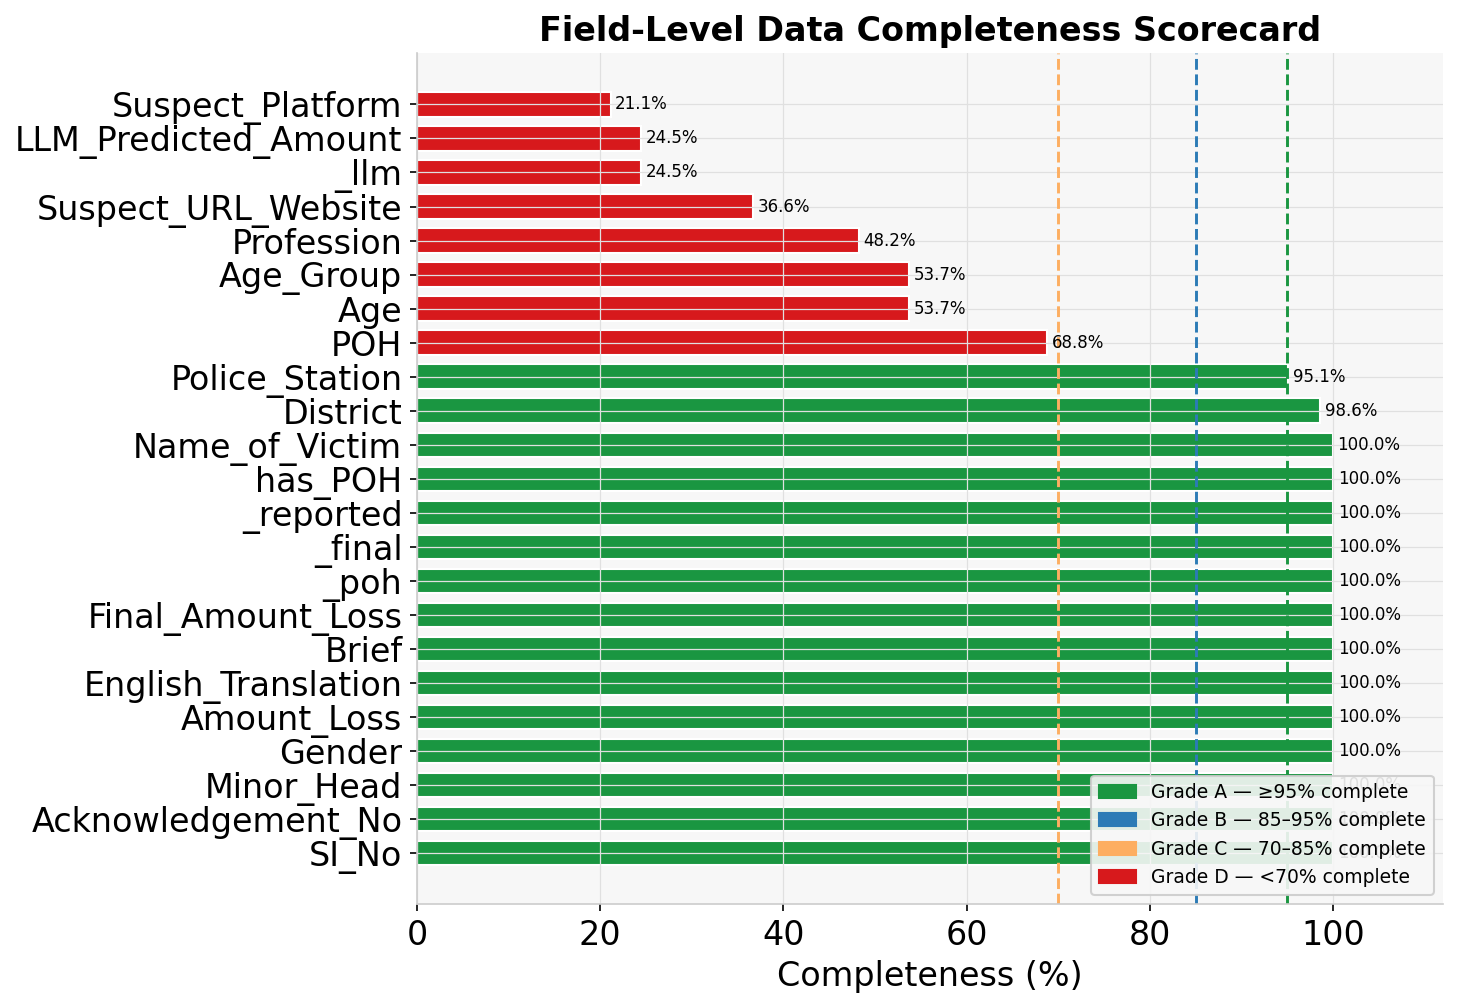

In [6]:
# ── 3.1: Completeness bar chart ───────────────────────────────────────────────
miss = (df.isnull().mean() * 100).sort_values()          # ascending = most complete on top

def grade_color(v):
    if v <= 5:  return C3      # green  — Grade A
    if v <= 15: return C1      # blue   — Grade B
    if v <= 30: return C4      # amber  — Grade C
    return C2                  # red    — Grade D

colors = [grade_color(v) for v in miss.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(miss.index, 100 - miss.values, color=colors, edgecolor='white', height=0.72)

ax.axvline(95, color=C3, ls='--', lw=1.4, label='Grade A threshold (≥95%)')
ax.axvline(85, color=C1, ls='--', lw=1.4, label='Grade B threshold (≥85%)')
ax.axvline(70, color=C4, ls='--', lw=1.4, label='Grade C threshold (≥70%)')

for bar, v in zip(bars, miss.values):
    compl = 100 - v
    ax.text(compl + 0.5, bar.get_y() + bar.get_height()/2,
            f'{compl:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Completeness (%)')
ax.set_xlim(0, 112)
ax.set_title('Field-Level Data Completeness Scorecard')

grade_patches = [
    mpatches.Patch(color=C3, label='Grade A — ≥95% complete'),
    mpatches.Patch(color=C1, label='Grade B — 85–95% complete'),
    mpatches.Patch(color=C4, label='Grade C — 70–85% complete'),
    mpatches.Patch(color=C2, label='Grade D — <70% complete'),
]
ax.legend(handles=grade_patches, loc='lower right', fontsize=9)

plt.tight_layout()
save('fig01_completeness_scorecard')
plt.show()

### 3.2 Nullity Matrix — Co-occurrence of Missing Fields

  Saved → fig02_nullity_matrix.png / .pdf


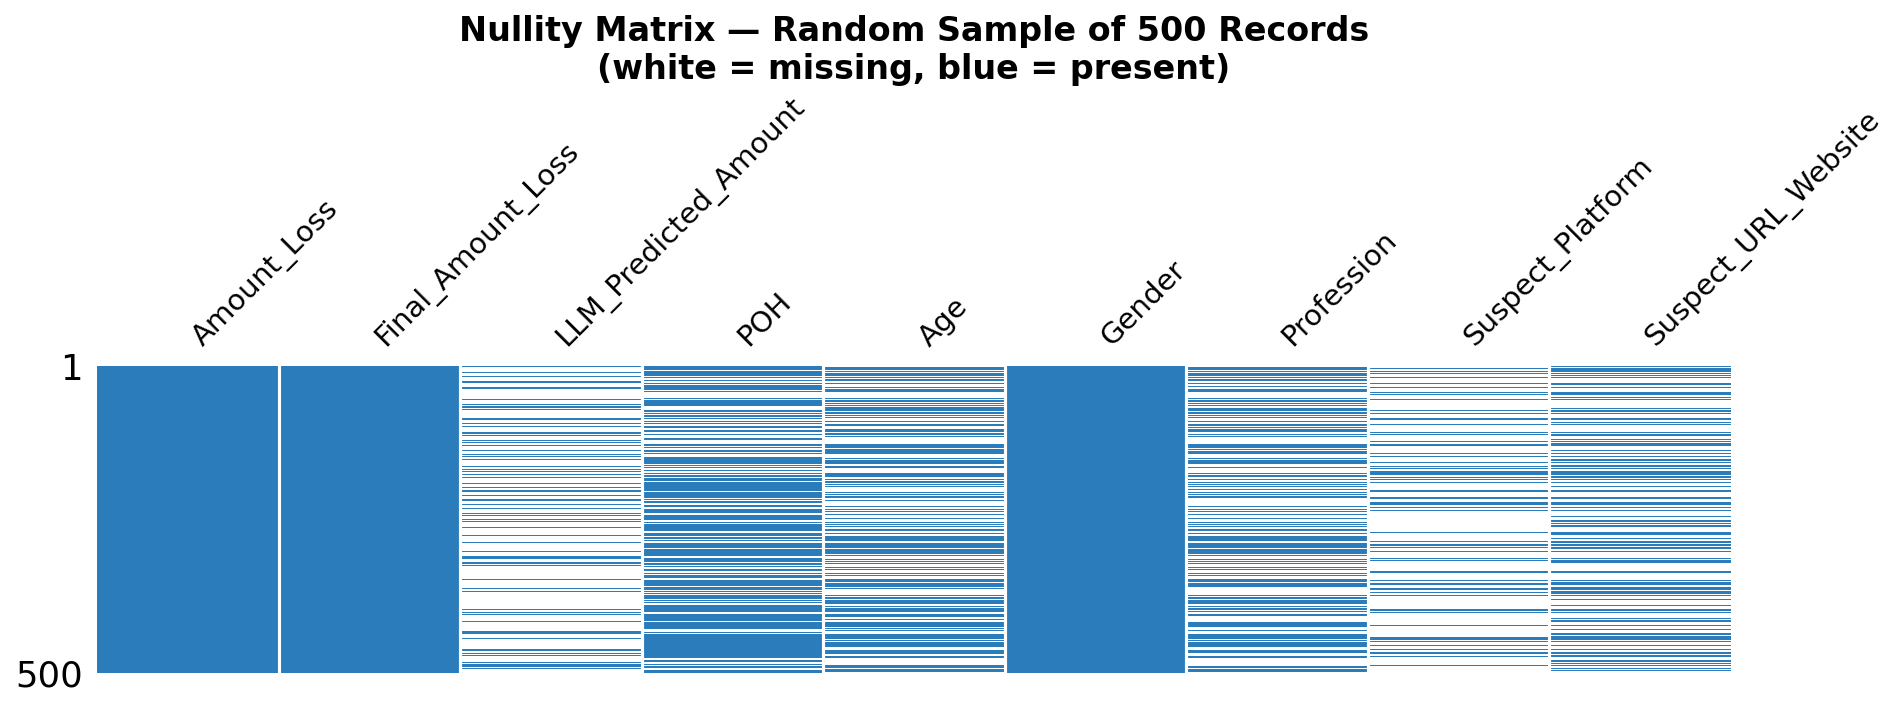

In [7]:
# ── 3.2: missingno nullity matrix ─────────────────────────────────────────────
KEY_COLS = ['Amount_Loss','Final_Amount_Loss','LLM_Predicted_Amount',
            'POH','Age','Gender','Profession','Suspect_Platform','Suspect_URL_Website']

sample_n = min(500, N)
fig, ax = plt.subplots(figsize=(13, 5))
msno.matrix(
    df[KEY_COLS].sample(sample_n, random_state=42),
    ax=ax, sparkline=False, fontsize=14,
    color=(0.17, 0.49, 0.73)
)
ax.set_title(f'Nullity Matrix — Random Sample of {sample_n} Records'
             f'\n(white = missing, blue = present)')
plt.tight_layout()
save('fig02_nullity_matrix')
plt.show()

### 3.3 Availability Heatmap by District

  Saved → fig03_availability_heatmap.png / .pdf


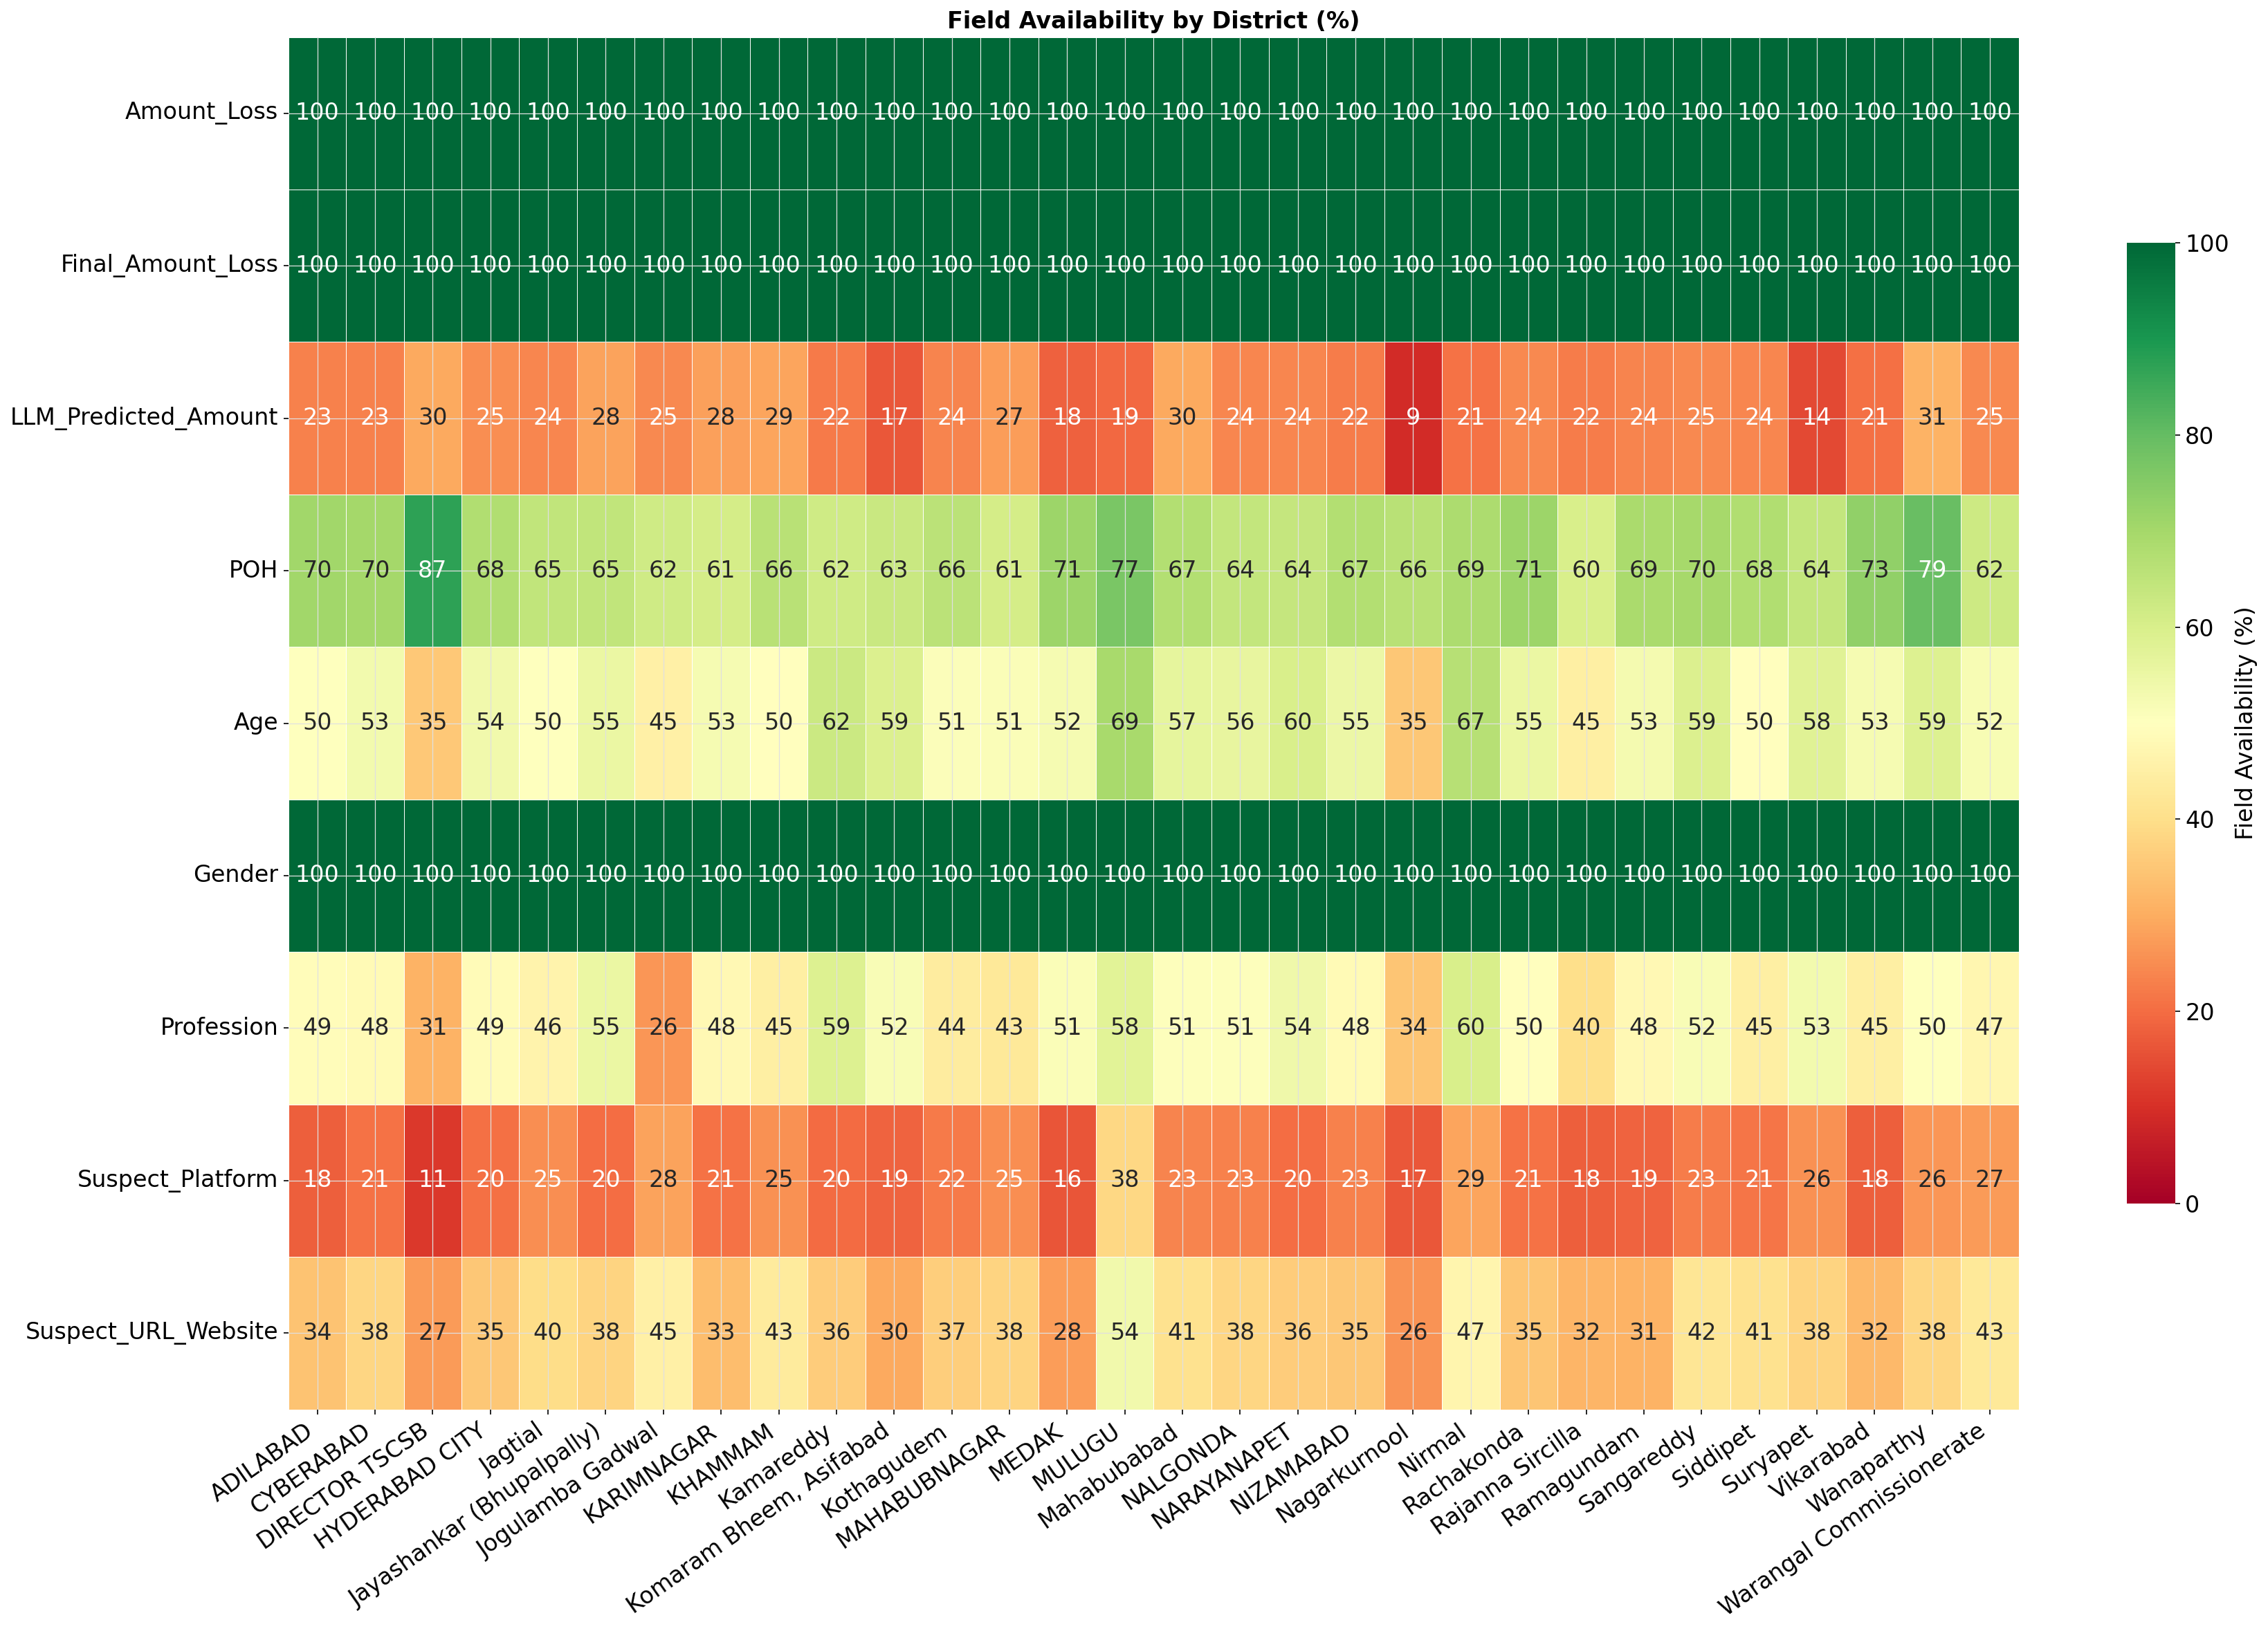

In [8]:
# ── 3.3: Availability heatmap ─────────────────────────────────────────────────
avail = (
    df.groupby('District')[KEY_COLS]
      .apply(lambda g: g.notnull().mean() * 100)
      .T
)

fig, ax = plt.subplots(figsize=(24, 16))
sns.heatmap(
    avail, ax=ax,
    cmap='RdYlGn', vmin=0, vmax=100,
    annot=True, fmt='.0f', linewidths=0.4,
    cbar_kws={'label': 'Field Availability (%)', 'shrink': 0.7}
)
ax.set_title('Field Availability by District (%)')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save('fig03_availability_heatmap')
plt.show()

### 3.4 Suspect Intelligence Availability (URL & Platform)

  Saved → fig04_suspect_intelligence.png / .pdf


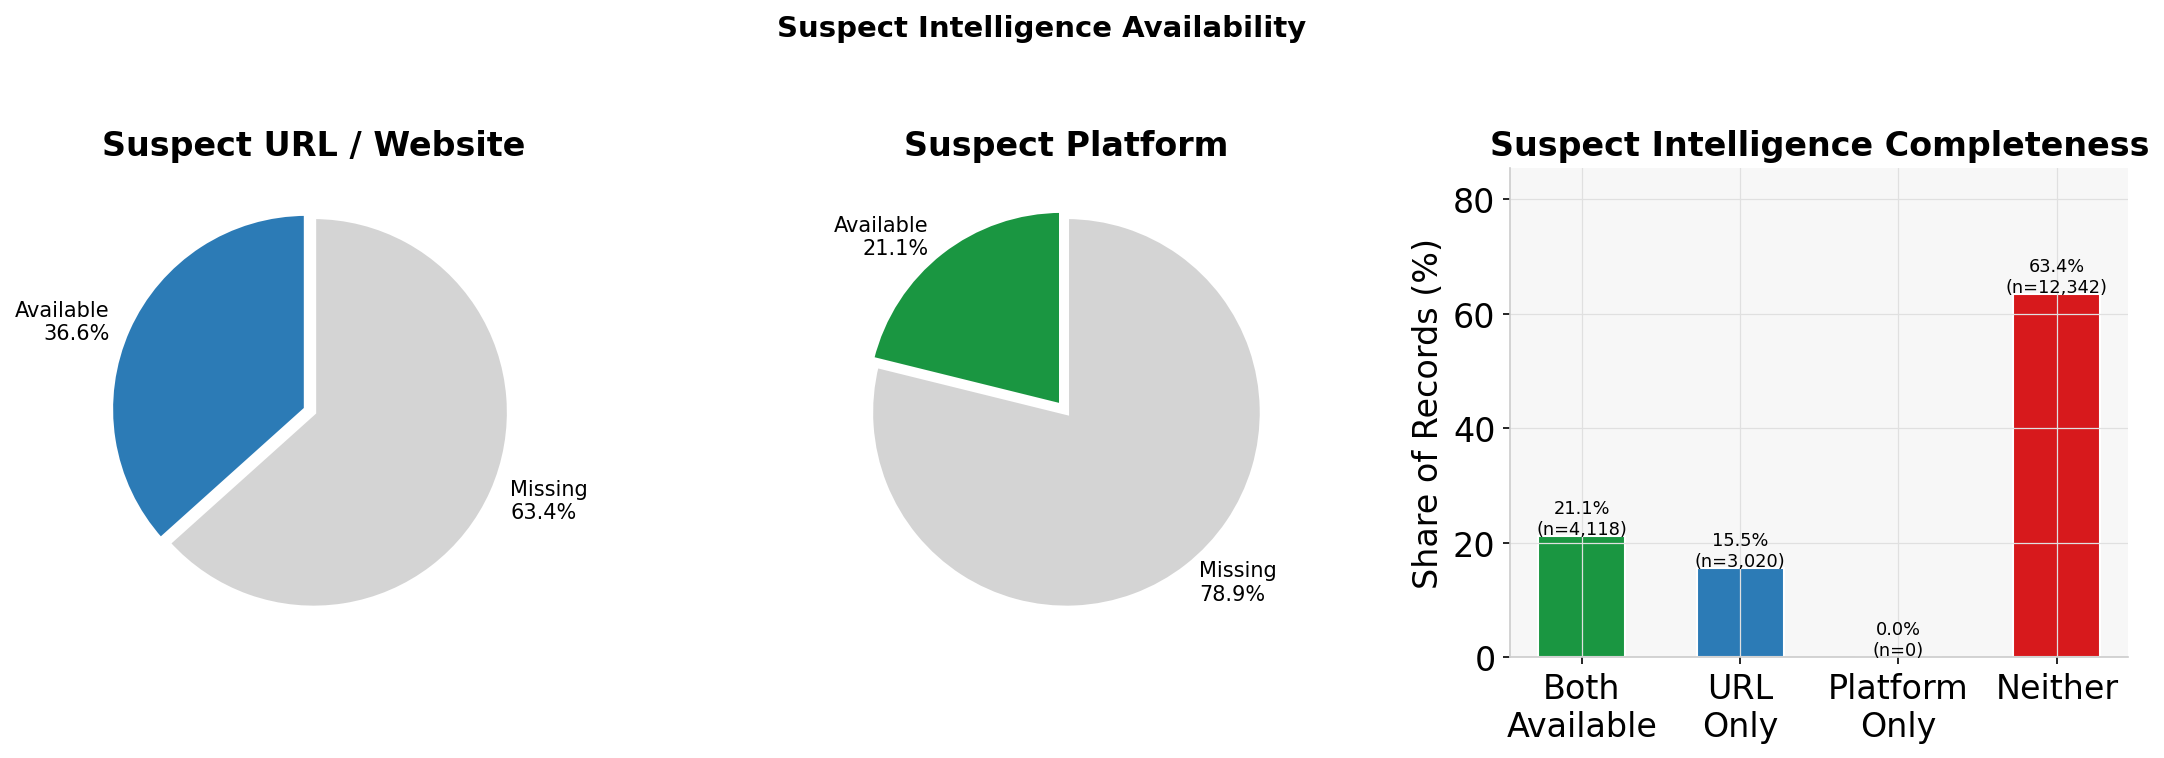

In [9]:
# ── 3.4: Suspect intelligence coverage ────────────────────────────────────────
url_y  = df['Suspect_URL_Website'].notnull().sum()
url_n  = N - url_y
plt_y  = df['Suspect_Platform'].notnull().sum()
plt_n  = N - plt_y
both   = (df['Suspect_URL_Website'].notnull() & df['Suspect_Platform'].notnull()).sum()
url_o  = (df['Suspect_URL_Website'].notnull() & df['Suspect_Platform'].isnull()).sum()
plt_o  = (df['Suspect_URL_Website'].isnull()  & df['Suspect_Platform'].notnull()).sum()
neither= (df['Suspect_URL_Website'].isnull()  & df['Suspect_Platform'].isnull()).sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# URL pie
axes[0].pie([url_y, url_n],
             labels=[f'Available\n{url_y/N*100:.1f}%', f'Missing\n{url_n/N*100:.1f}%'],
             colors=[C1, '#d4d4d4'], startangle=90,
             explode=[0.04, 0], wedgeprops={'edgecolor':'white','linewidth':2.5},
             textprops={'fontsize':10})
axes[0].set_title('Suspect URL / Website')

# Platform pie
axes[1].pie([plt_y, plt_n],
             labels=[f'Available\n{plt_y/N*100:.1f}%', f'Missing\n{plt_n/N*100:.1f}%'],
             colors=[C3, '#d4d4d4'], startangle=90,
             explode=[0.04, 0], wedgeprops={'edgecolor':'white','linewidth':2.5},
             textprops={'fontsize':10})
axes[1].set_title('Suspect Platform')

# Compound bar
cats   = ['Both\nAvailable', 'URL\nOnly', 'Platform\nOnly', 'Neither']
counts = [both, url_o, plt_o, neither]
cols   = [C3, C1, C4, C2]
b = axes[2].bar(cats, [c/N*100 for c in counts], color=cols, edgecolor='white', width=0.55)
for bar, c in zip(b, counts):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{c/N*100:.1f}%\n(n={c:,})', ha='center', fontsize=8.5)
axes[2].set_ylabel('Share of Records (%)')
axes[2].set_title('Suspect Intelligence Completeness')
axes[2].set_ylim(0, max([c/N*100 for c in counts])*1.35)

plt.suptitle('Suspect Intelligence Availability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save('fig04_suspect_intelligence')
plt.show()

### 3.5 Payment on Hold (POH) — Availability & Recovery

  Saved → fig05_poh_analysis.png / .pdf


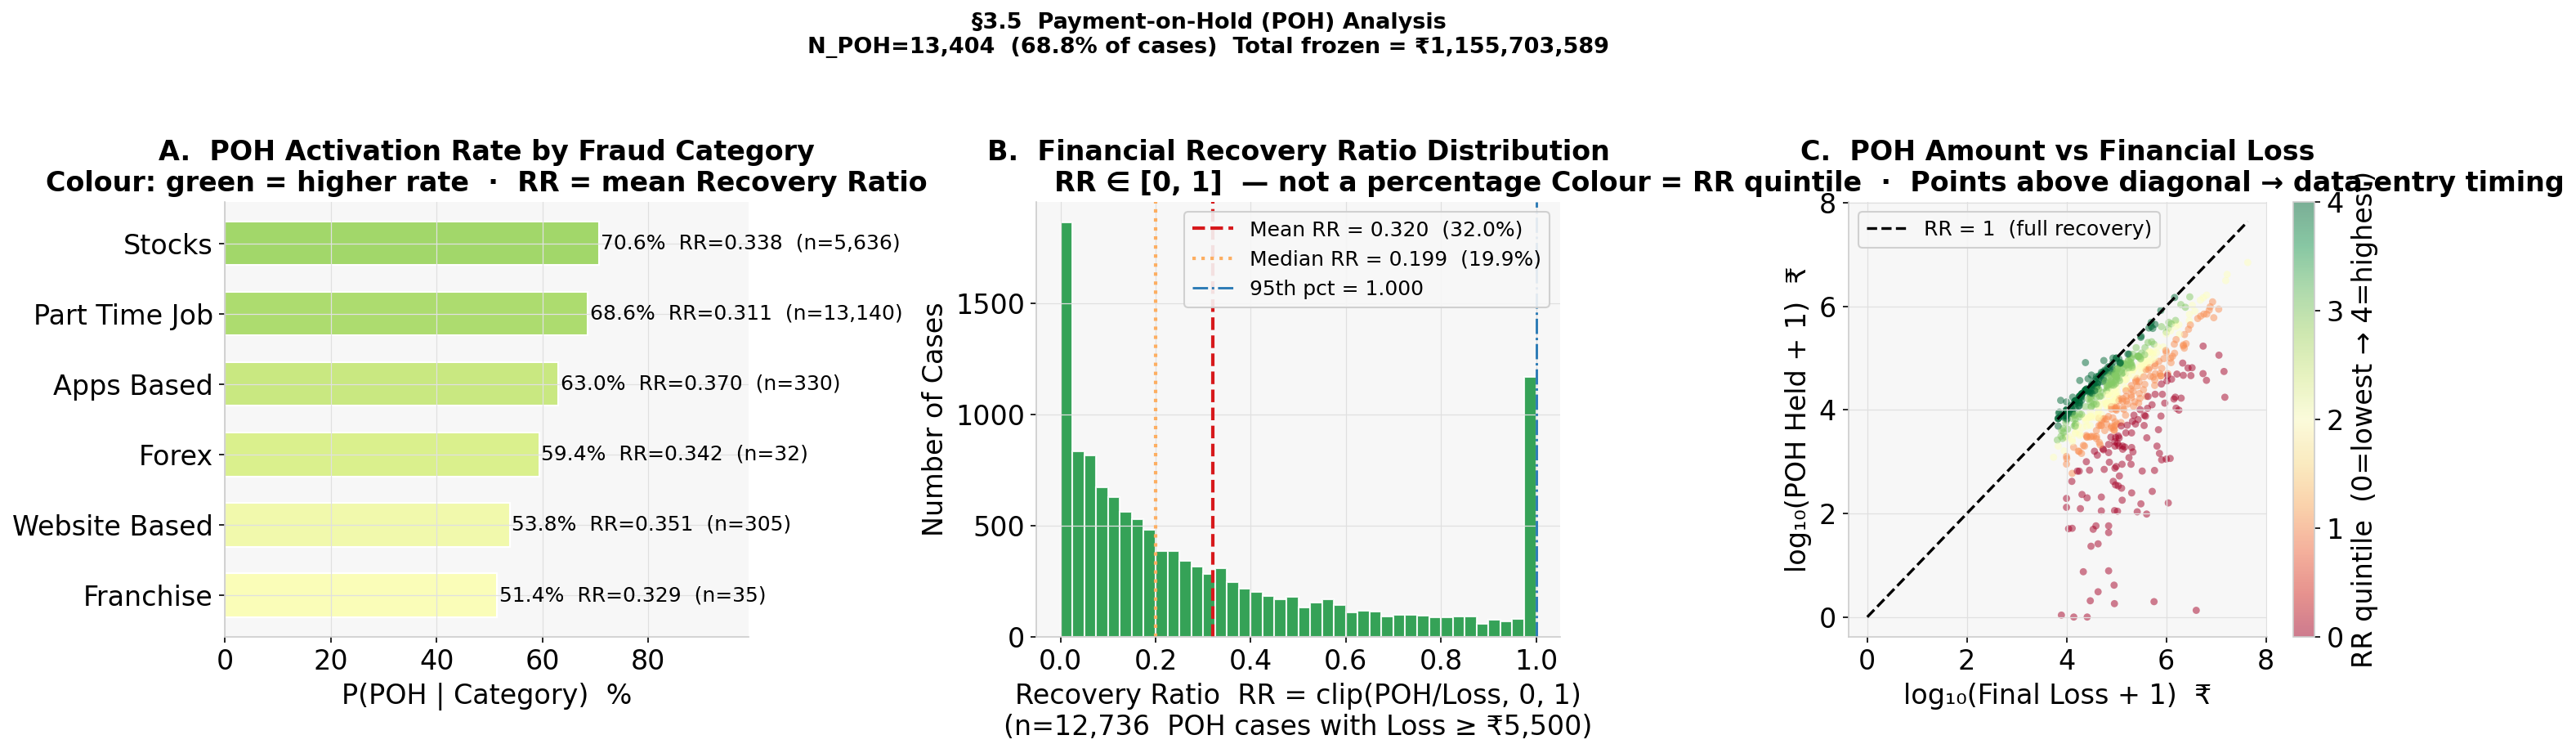

Overall POH activation rate  : 68.8%  (13,404 of 19,480 cases)
Total POH held               : ₹1,155,703,589
Valid RR cases (≥₹5,500) : 12,736
Mean  RR                     : 0.3205  (32.0%)
Median RR                    : 0.1995  (19.9%)
95th-pct RR                  : 1.0000  (100.0%)


In [10]:

# ── §3.5: POH Analysis ────────────────────────────────────────────────────────
#
# ┌── FINANCIAL RECOVERY RATIO — formal definition ─────────────────────────── ┐
# │                                                                              │
# │  RR_i  =  min(POH_held_i, Final_Loss_i) / Final_Loss_i  ∈ [0, 1]          │
# │                                                                              │
# │  Implemented as:  RR_i = clip(_poh_i / _final_i, 0, 1)                    │
# │                                                                              │
# │  Domain constraints:                                                        │
# │    • Final_Loss_i > 0  (undefined otherwise → NaN)                         │
# │    • POH_held_i  ≥ 0   (holds are non-negative)                            │
# │    • RR_i ∈ [0, 1]     — cap enforced by clip(0, 1)                       │
# │      rationale: POH > Final_Loss reflects data-entry timing error          │
# │      (POH logged before loss is finalised); treated as censored at 1.      │
# │                                                                              │
# │  Small-denominator guard: Final_Loss < ₹1,000 excluded from RR-based      │
# │  statistics (rounding errors inflate RR at tiny denominators).             │
# └──────────────────────────────────────────────────────────────────────────── ┘
#
# IMPORTANT: ALL operations here use a LOCAL copy poh_df — df is NEVER mutated.
# ─────────────────────────────────────────────────────────────────────────────

PREFIX = 'Business & Investment Fraud - '

# 1. Local working frame — never mutate global df
poh_df = df[df['has_POH'] & (df['_final'] > 0) & (df['_poh'] >= 0)].copy()
poh_df['RR']       = (poh_df['_poh'] / poh_df['_final']).clip(0, 1)
poh_df['Category'] = poh_df['Minor_Head'].str.replace(PREFIX, '', regex=False).str.strip()

# 2. Small-denominator guard
LOSS_FLOOR   = max(1_000, float(poh_df['_final'].quantile(0.05)))
poh_valid    = poh_df[poh_df['_final'] >= LOSS_FLOOR].copy()

# 3. Category aggregation (computed on ALL df, not just POH subset)
cat_df = df.copy()
cat_df['Category'] = cat_df['Minor_Head'].str.replace(PREFIX, '', regex=False).str.strip()

rr_by_cat  = (poh_valid.groupby('Category')['RR']
               .agg(mean_RR='mean', median_RR='median', n_poh='count').reset_index())
poh_by_cat = (cat_df.groupby('Category', sort=False)
               .agg(poh_rate=('has_POH', 'mean'), n=('SI_No', 'count'))
               .reset_index()
               .merge(rr_by_cat, on='Category', how='left'))
poh_by_cat = (poh_by_cat[poh_by_cat['n'] >= 30]
               .sort_values('poh_rate', ascending=True)
               .reset_index(drop=True))

# 4. RR distribution stats
RR_plot   = poh_valid['RR']
RR_plot   = RR_plot[RR_plot <= RR_plot.quantile(0.99)]
mean_RR   = float(RR_plot.mean())
median_RR = float(RR_plot.median())
p95_RR    = float(RR_plot.quantile(0.95))

# 5. Three-panel figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel A — P(POH | category) coloured by rate, annotated with RR
bar_cols = [plt.cm.RdYlGn(v) for v in poh_by_cat['poh_rate'].values]
bars = axes[0].barh(poh_by_cat['Category'], poh_by_cat['poh_rate']*100,
                    color=bar_cols, edgecolor='white', height=0.62)
for bar, pr, rr_v, n in zip(bars, poh_by_cat['poh_rate']*100,
                              poh_by_cat['mean_RR'].fillna(0),
                              poh_by_cat['n']):
    axes[0].text(pr + 0.4, bar.get_y() + bar.get_height()/2,
                 f'{pr:.1f}%  RR={rr_v:.3f}  (n={n:,})', va='center', fontsize=12)
axes[0].set_xlabel('P(POH | Category)  %')
axes[0].set_xlim(0, poh_by_cat['poh_rate'].max() * 140)
axes[0].set_title('A.  POH Activation Rate by Fraud Category\n'
                   'Colour: green = higher rate  ·  RR = mean Recovery Ratio',
                   fontweight='bold')

# Panel B — RR distribution ∈ [0,1]
axes[1].hist(RR_plot, bins=40, color=C3, edgecolor='white', alpha=0.88)
axes[1].axvline(mean_RR,   color=C2, lw=2.0, ls='--',
                label=f'Mean RR = {mean_RR:.3f}  ({mean_RR*100:.1f}%)')
axes[1].axvline(median_RR, color=C4, lw=2.0, ls=':',
                label=f'Median RR = {median_RR:.3f}  ({median_RR*100:.1f}%)')
axes[1].axvline(p95_RR,    color=C1, lw=1.4, ls='-.',
                label=f'95th pct = {p95_RR:.3f}')
axes[1].set_xlabel(f'Recovery Ratio  RR = clip(POH/Loss, 0, 1)\n'
                   f'(n={len(RR_plot):,}  POH cases with Loss ≥ ₹{LOSS_FLOOR:,.0f})')
axes[1].set_ylabel('Number of Cases')
axes[1].set_title('B.  Financial Recovery Ratio Distribution\n'
                   'RR ∈ [0, 1]  — not a percentage', fontweight='bold')
axes[1].legend(fontsize=12)

# Panel C — log(POH) vs log(Loss), coloured by RR quintile
sub = poh_valid.sample(min(600, len(poh_valid)), random_state=42).copy()
sub['RR_q'] = pd.qcut(sub['RR'], q=5, labels=False, duplicates='drop')
sc = axes[2].scatter(np.log10(sub['_final']+1), np.log10(sub['_poh']+1),
                     c=sub['RR_q'], cmap='RdYlGn', alpha=0.5, s=18, linewidths=0)
plt.colorbar(sc, ax=axes[2], label='RR quintile  (0=lowest → 4=highest)')
lo = min(np.log10(sub['_final']+1).min(), np.log10(sub['_poh']+1).min())
hi = max(np.log10(sub['_final']+1).max(), np.log10(sub['_poh']+1).max())
axes[2].plot([lo, hi], [lo, hi], 'k--', lw=1.6, label='RR = 1  (full recovery)')
axes[2].set_xlabel('log₁₀(Final Loss + 1)  ₹')
axes[2].set_ylabel('log₁₀(POH Held + 1)  ₹')
axes[2].set_title('C.  POH Amount vs Financial Loss\n'
                   'Colour = RR quintile  ·  Points above diagonal → data-entry timing',
                   fontweight='bold')
axes[2].legend(fontsize=12)

plt.suptitle('§3.5  Payment-on-Hold (POH) Analysis\n'
             f'N_POH={df["has_POH"].sum():,}  ({df["has_POH"].mean()*100:.1f}% of cases)  '
             f'Total frozen = ₹{df["_poh"].sum():,.0f}',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
save('fig05_poh_analysis')
plt.show()

# Summary stats — all from computed objects
print(f'Overall POH activation rate  : {df["has_POH"].mean()*100:.1f}%  '
      f'({df["has_POH"].sum():,} of {len(df):,} cases)')
print(f'Total POH held               : ₹{df["_poh"].sum():,.0f}')
print(f'Valid RR cases (≥₹{LOSS_FLOOR:,.0f}) : {len(poh_valid):,}')
print(f'Mean  RR                     : {mean_RR:.4f}  ({mean_RR*100:.1f}%)')
print(f'Median RR                    : {median_RR:.4f}  ({median_RR*100:.1f}%)')
print(f'95th-pct RR                  : {p95_RR:.4f}  ({p95_RR*100:.1f}%)')


In [11]:
print('POH Analysis Summary:')
print('='*65)
print(f'Overall POH activation rate  : {df["has_POH"].mean()*100:.1f}%  '\
      f'({df["has_POH"].sum():,} of {len(df):,} cases)')
print(f'Total POH held               : ₹{df["_poh"].sum():,.0f}')
print(f'Valid RR cases (\u2265\u20b9{LOSS_FLOOR:,.0f}) : {len(poh_valid):,}')
print(f'Mean  RR                     : {mean_RR:.4f}  ({mean_RR*100:.1f}%)')
print(f'Median RR                    : {median_RR:.4f}  ({median_RR*100:.1f}%)')
print(f'95th-pct RR                  : {p95_RR:.4f}  ({p95_RR*100:.1f}%)')

print('\nPOH Activation and Recovery Ratio by Fraud Category:')
print(poh_by_cat.to_string(index=False))

POH Analysis Summary:
Overall POH activation rate  : 68.8%  (13,404 of 19,480 cases)
Total POH held               : ₹1,155,703,589
Valid RR cases (≥₹5,500) : 12,736
Mean  RR                     : 0.3205  (32.0%)
Median RR                    : 0.1995  (19.9%)
95th-pct RR                  : 1.0000  (100.0%)

POH Activation and Recovery Ratio by Fraud Category:
     Category  poh_rate     n  mean_RR  median_RR  n_poh
    Franchise  0.514286    35 0.329251   0.065824   18.0
Website Based  0.537705   305 0.350577   0.247927  151.0
        Forex  0.593750    32 0.342451   0.164271   19.0
   Apps Based  0.630303   330 0.370006   0.259259  201.0
Part Time Job  0.685921 13140 0.310762   0.195622 8494.0
       Stocks  0.706352  5636 0.338097   0.203939 3852.0


---
## 4. DATA INTEGRITY ANALYSIS
### 4.1 Amount Reporting Consistency: Victim-Reported vs LLM-Extracted

In [12]:
# ── 4.1a: Compute discrepancy metrics ─────────────────────────────────────────
comp = df[['_reported','_final','Minor_Head','District']].dropna(subset=['_reported','_final'])
comp = comp[(comp['_reported'] > 0) & (comp['_final'] > 0)].copy()

comp['abs_diff']    = (comp['_reported'] - comp['_final']).abs()
comp['rel_diff_pct']= comp['abs_diff'] / comp['_final'] * 100
comp['direction']   = np.where(comp['_reported'] > comp['_final'], 'Over-reported',
                      np.where(comp['_reported'] < comp['_final'], 'Under-reported', 'Exact match'))

dir_counts = comp['direction'].value_counts()
t5  = (comp['rel_diff_pct'] <=  5).mean() * 100
t10 = (comp['rel_diff_pct'] <= 10).mean() * 100
t20 = (comp['rel_diff_pct'] <= 20).mean() * 100

print('Amount Integrity Report  (Victim-Reported vs LLM-Extracted Final Amount)')
print('='*68)
print(f'  Records compared                 : {len(comp):,}')
print(f'  Over-reported (victim > LLM)     : {dir_counts.get("Over-reported",0)/len(comp)*100:.1f}%')
print(f'  Under-reported (victim < LLM)    : {dir_counts.get("Under-reported",0)/len(comp)*100:.1f}%')
print(f'  Match within  5%                 : {t5:.1f}%')
print(f'  Match within 10%                 : {t10:.1f}%')
print(f'  Match within 20%                 : {t20:.1f}%')
print(f'  Mean absolute discrepancy        : ₹{comp.abs_diff.mean():,.0f}')
print(f'  Median relative discrepancy      : {comp.rel_diff_pct.median():.1f}%')

Amount Integrity Report  (Victim-Reported vs LLM-Extracted Final Amount)
  Records compared                 : 19,480
  Over-reported (victim > LLM)     : 0.0%
  Under-reported (victim < LLM)    : 9.7%
  Match within  5%                 : 91.7%
  Match within 10%                 : 92.3%
  Match within 20%                 : 93.3%
  Mean absolute discrepancy        : ₹668,821
  Median relative discrepancy      : 0.0%


In [13]:
print("Exact equality ratio:",
      (comp['_reported'] == comp['_final']).mean())

print("Mean absolute difference:",
      np.mean(np.abs(comp['_reported'] - comp['_final'])))

print(comp[['_reported', '_final']].describe())


Exact equality ratio: 0.9027720739219712
Mean absolute difference: 668821.1326087415
          _reported        _final
count  1.948000e+04  1.948000e+04
mean   4.289347e+05  1.097756e+06
std    2.177582e+06  7.179854e+07
min    1.000000e+00  1.000000e+00
25%    2.010000e+04  2.166000e+04
50%    6.200000e+04  6.700000e+04
75%    2.062340e+05  2.282295e+05
max    1.480000e+08  1.000000e+10


  Saved → fig06_amount_integrity.png / .pdf


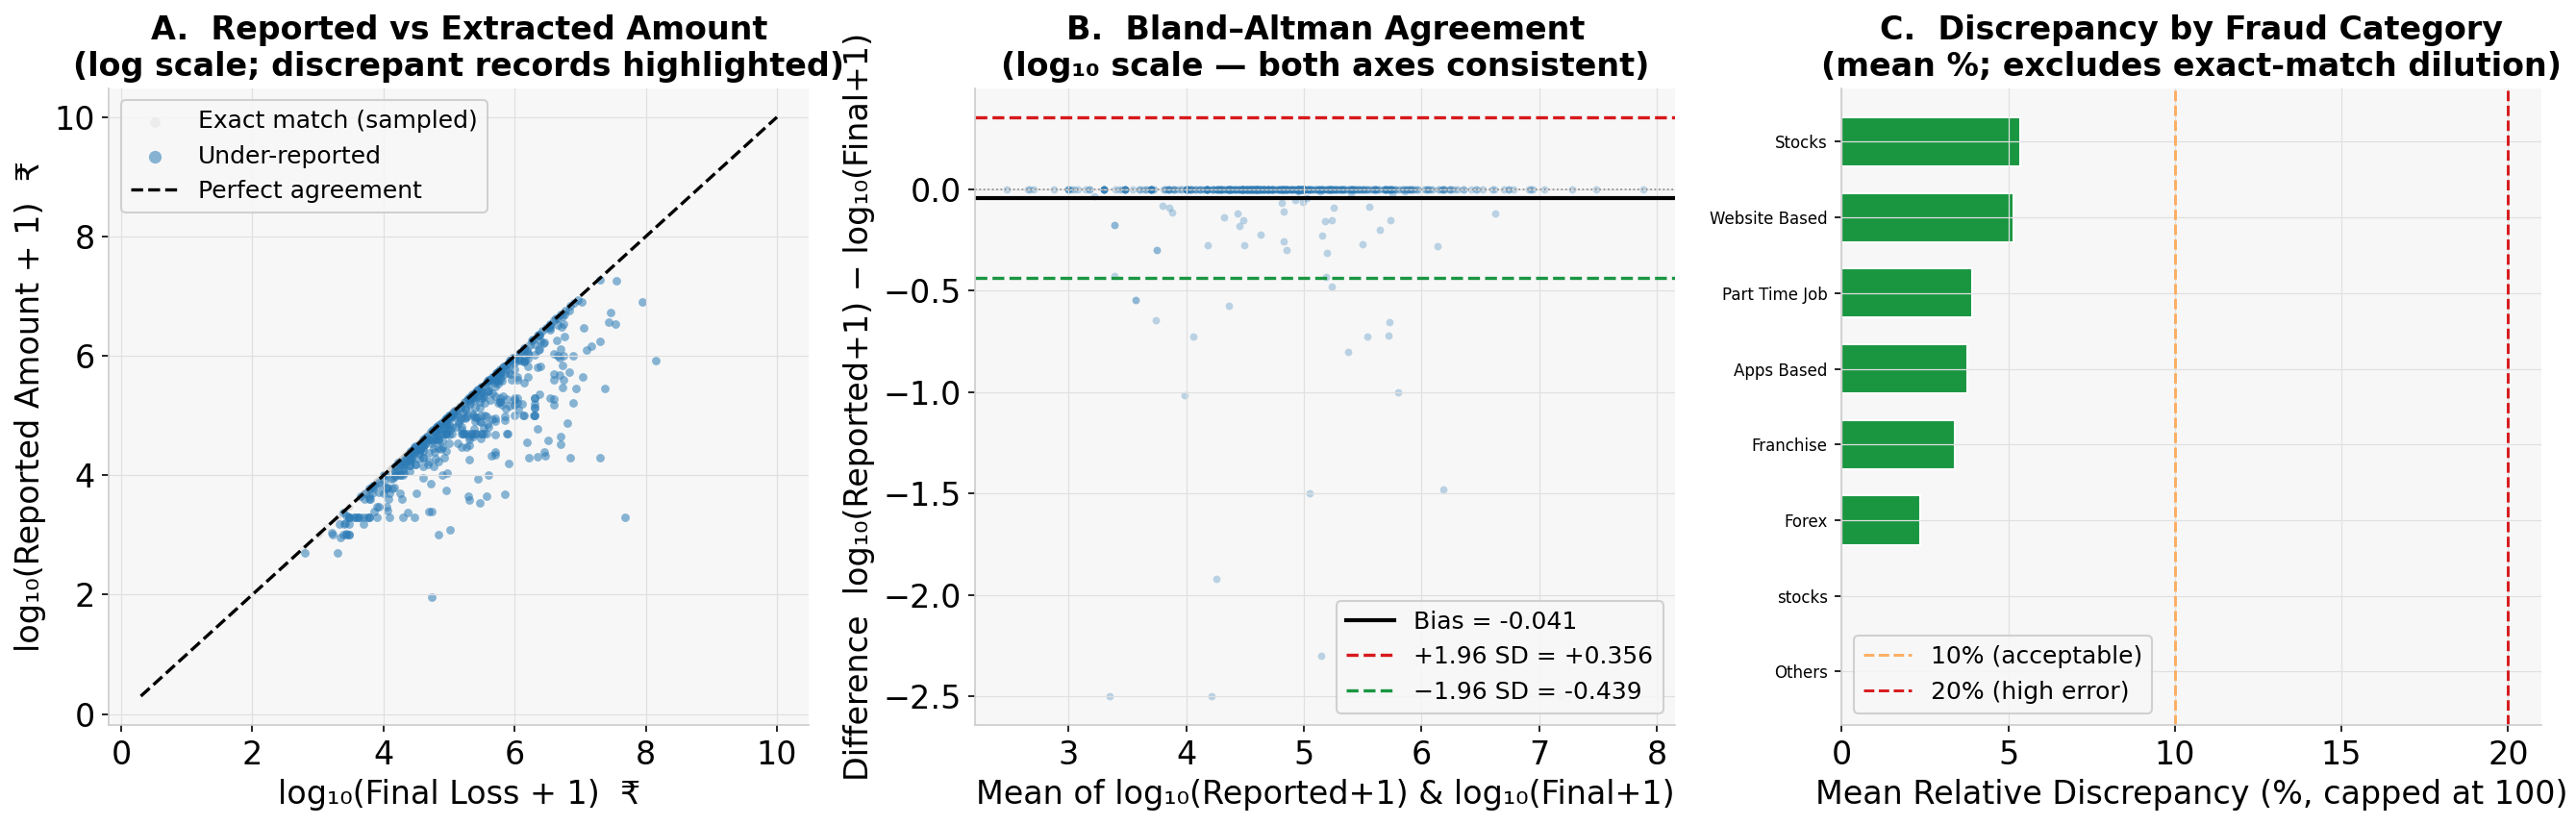

In [14]:

# ── 4.1b: Three-panel integrity figure ────────────────────────────────────────
#
# FIXES APPLIED vs original cell:
#   Panel 1 — Scatter now highlights only the 9.7% discrepant records
#             (exact matches are shown as a density background, not dominating)
#   Panel 2 — Bland-Altman: BOTH axes use log₁₀ scale (self-consistent)
#             ba_diff = log₁₀(reported+1) − log₁₀(final+1)  ∈ [−2, 2]
#             eliminates the mixed-scale bug (raw diff / 1e3 on log mean axis)
#   Panel 3 — Minor_Head labels shortened by stripping the common prefix
#             "Business & Investment Fraud - "
#             y-axis uses mean rel_diff_pct (not median which is 0 for most)
#             to make the bars informative; clipped at 100% for readability
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── PANEL 1: Scatter — reported vs final (log scale) ─────────────────────────
# Split into exact matches vs discrepant so the 90% exact blob
# doesn't visually bury the informative 10%.
exact      = comp[comp['direction'] == 'Exact match']
discrepant = comp[comp['direction'] != 'Exact match']

# Sample each stratum separately to keep discrepant points visible
n_exact = min(300, len(exact))
n_disc  = min(500, len(discrepant))
samp_ex  = exact.sample(n_exact,      random_state=42) if n_exact  > 0 else exact
samp_dis = discrepant.sample(n_disc,  random_state=42) if n_disc   > 0 else discrepant

# Exact matches: faint grey
axes[0].scatter(
    np.log10(samp_ex['_final']    + 1),
    np.log10(samp_ex['_reported'] + 1),
    c='#cccccc', alpha=0.25, s=12, linewidths=0, label='Exact match (sampled)')

# Discrepant: colour by direction
dir_col = {'Over-reported': C2, 'Under-reported': C1}
for direction, grp in samp_dis.groupby('direction'):
    axes[0].scatter(
        np.log10(grp['_final']    + 1),
        np.log10(grp['_reported'] + 1),
        c=dir_col.get(direction, C4),
        alpha=0.55, s=18, linewidths=0, label=direction)

lims = [np.log10(comp['_final'].min() + 1),
        np.log10(comp['_final'].max() + 1)]
axes[0].plot(lims, lims, 'k--', lw=1.6, label='Perfect agreement')
axes[0].set_xlabel('log₁₀(Final Loss + 1)  ₹')
axes[0].set_ylabel('log₁₀(Reported Amount + 1)  ₹')
axes[0].set_title('A.  Reported vs Extracted Amount\n(log scale; discrepant records highlighted)', fontweight='bold')
axes[0].legend(fontsize=12, markerscale=1.5)

# ── PANEL 2: Bland-Altman (log scale, self-consistent) ───────────────────────
# Both axes on log₁₀ scale so the mean and difference are commensurate.
# Reference: Bland & Altman (1986) — use transformed data when raw
# scale is heavily right-skewed (as here: mean ₹668K, median ₹0 diff).
log_rep   = np.log10(comp['_reported'] + 1)
log_fin   = np.log10(comp['_final']    + 1)
ba_mean   = (log_rep + log_fin) / 2                  # mean of two log measurements
ba_diff   = (log_rep - log_fin).clip(-2.5, 2.5)      # log-scale difference, clipped

md = ba_diff.mean()
sd = ba_diff.std()
lo_loa = md - 1.96 * sd
hi_loa = md + 1.96 * sd

ba_samp = pd.DataFrame({'mean': ba_mean, 'diff': ba_diff}) \
            .sample(min(600, len(comp)), random_state=1)

axes[1].scatter(ba_samp['mean'], ba_samp['diff'],
                alpha=0.3, s=14, color=C1, linewidths=0)
axes[1].axhline(md,     color='k',  lw=2.0, label=f'Bias = {md:+.3f}')
axes[1].axhline(hi_loa, color=C2,  lw=1.6, ls='--',
                label=f'+1.96 SD = {hi_loa:+.3f}')
axes[1].axhline(lo_loa, color=C3,  lw=1.6, ls='--',
                label=f'−1.96 SD = {lo_loa:+.3f}')
axes[1].axhline(0,      color='#888', lw=0.8, ls=':')
axes[1].set_xlabel('Mean of log₁₀(Reported+1) & log₁₀(Final+1)')
axes[1].set_ylabel('Difference  log₁₀(Reported+1) − log₁₀(Final+1)')
axes[1].set_title('B.  Bland–Altman Agreement\n(log₁₀ scale — both axes consistent)', fontweight='bold')
axes[1].legend(fontsize=12)

# ── PANEL 3: Discrepancy by crime category ────────────────────────────────────
# Strip the common prefix so labels fit; use MEAN rel_diff_pct because
# median = 0 for most categories (90%+ exact-match records dilute the median).
comp['_mh_short'] = (
    comp['Minor_Head']
    .str.replace('Business & Investment Fraud - ', '', regex=False)
    .str.replace('Business & Investment Fraud',    'B&I Fraud', regex=False)
    .str.strip()
)

disc_cat = (
    comp.groupby('_mh_short')['rel_diff_pct']
    .mean()                    # mean to avoid 0-median collapse
    .clip(upper=100)           # cap at 100% for readability
    .dropna()
    .sort_values(ascending=True)
)

cols3 = [C2 if v > 20 else C1 if v > 10 else C3 for v in disc_cat.values]

axes[2].barh(disc_cat.index, disc_cat.values,
             color=cols3, edgecolor='white', height=0.65)
axes[2].axvline(10, color=C4, ls='--', lw=1.4, label='10% (acceptable)')
axes[2].axvline(20, color=C2, ls='--', lw=1.4, label='20% (high error)')
axes[2].set_xlabel('Mean Relative Discrepancy (%, capped at 100)')
axes[2].set_title('C.  Discrepancy by Fraud Category\n(mean %; excludes exact-match dilution)', fontweight='bold')
axes[2].legend(fontsize=12)
axes[2].tick_params(axis='y', labelsize=8)

plt.tight_layout()
save('fig06_amount_integrity')
plt.show()


In [15]:
print('Amount Integrity Report  (Victim-Reported vs LLM-Extracted Final Amount)')
print('='*68)
print(f'  Records compared                 : {len(comp):,}')
print(f'  Over-reported (victim > LLM)     : {dir_counts.get("Over-reported",0)/len(comp)*100:.1f}%')
print(f'  Under-reported (victim < LLM)    : {dir_counts.get("Under-reported",0)/len(comp)*100:.1f}%')
print(f'  Match within  5%                 : {t5:.1f}%')
print(f'  Match within 10%                 : {t10:.1f}%')
print(f'  Match within 20%                 : {t20:.1f}%')
print(f'  Mean absolute discrepancy        : ₹{comp.abs_diff.mean():,.0f}')
print(f'  Median relative discrepancy      : {comp.rel_diff_pct.median():.1f}%')

print('\nExact equality ratio:')
print((comp['_reported'] == comp['_final']).mean())

print('\nMean absolute difference:')
print(np.mean(np.abs(comp['_reported'] - comp['_final'])))

print('\nDescriptive statistics for _reported and _final:')
print(comp[['_reported', '_final']].describe().to_string())

print('\nDiscrepancy by Fraud Category (Mean Relative Discrepancy %):')
print(disc_cat.to_string())

Amount Integrity Report  (Victim-Reported vs LLM-Extracted Final Amount)
  Records compared                 : 19,480
  Over-reported (victim > LLM)     : 0.0%
  Under-reported (victim < LLM)    : 9.7%
  Match within  5%                 : 91.7%
  Match within 10%                 : 92.3%
  Match within 20%                 : 93.3%
  Mean absolute discrepancy        : ₹668,821
  Median relative discrepancy      : 0.0%

Exact equality ratio:
0.9027720739219712

Mean absolute difference:
668821.1326087415

Descriptive statistics for _reported and _final:
          _reported        _final
count  1.948000e+04  1.948000e+04
mean   4.289347e+05  1.097756e+06
std    2.177582e+06  7.179854e+07
min    1.000000e+00  1.000000e+00
25%    2.010000e+04  2.166000e+04
50%    6.200000e+04  6.700000e+04
75%    2.062340e+05  2.282295e+05
max    1.480000e+08  1.000000e+10

Discrepancy by Fraud Category (Mean Relative Discrepancy %):
_mh_short
Others           0.000000
stocks           0.000000
Forex          

### 4.2 Cross-Field Anomaly Detection

  Saved → fig07_anomaly_report.png / .pdf


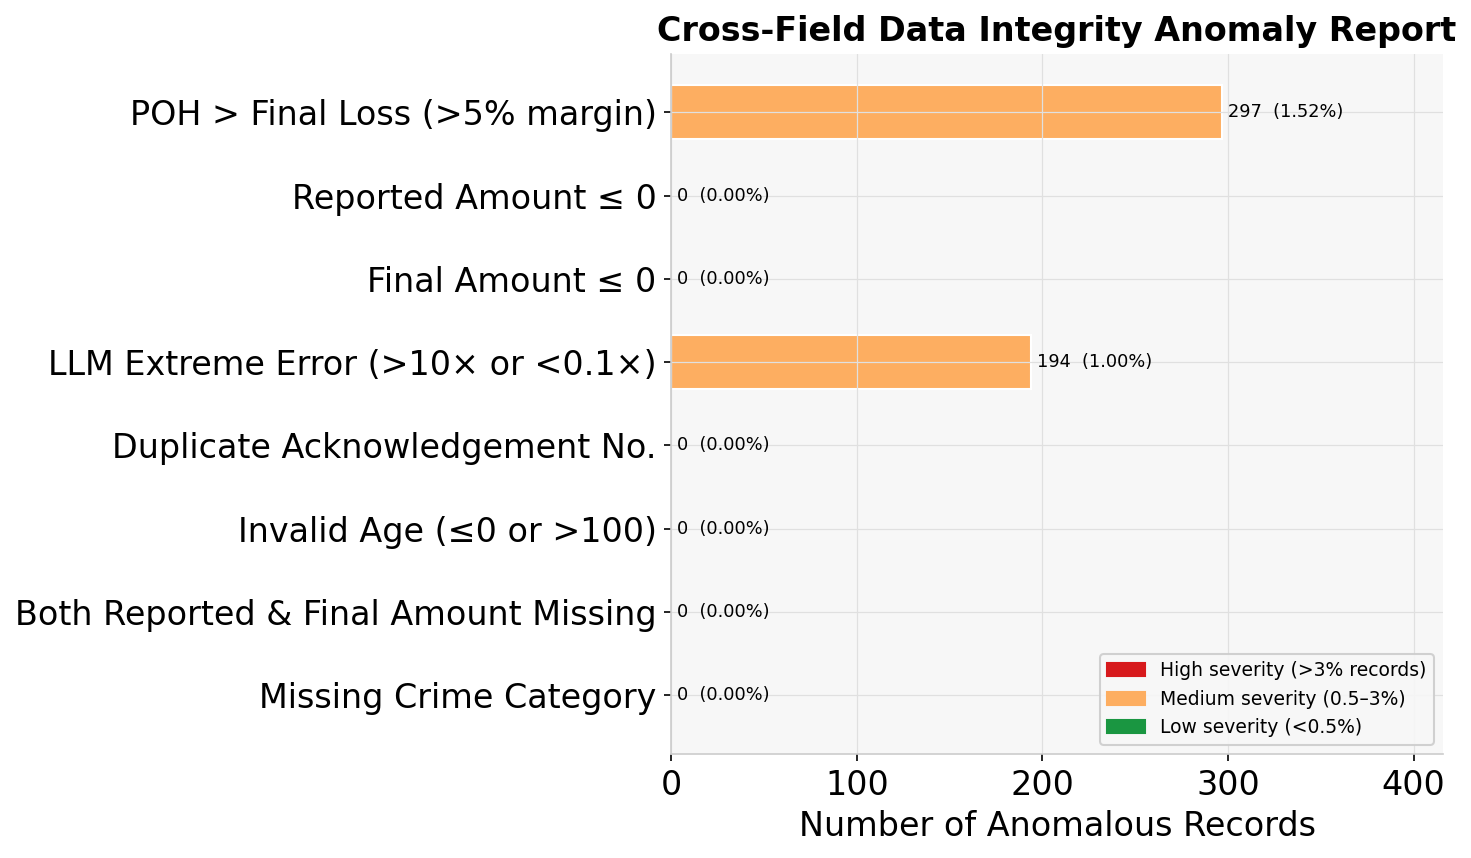


Anomaly types detected : 2/8
Total flagged records  : 491  (note: records may appear in multiple checks)


In [16]:
# ── 4.2: Integrity anomaly checklist ──────────────────────────────────────────
anomalies = {}

# A: POH > Final Amount (impossible — held more than was lost)
a1 = df[(df['_poh'] > 0) & df['_final'].notnull() & (df['_poh'] > df['_final'] * 1.05)]
anomalies['POH > Final Loss (>5% margin)'] = len(a1)

# B: Amount_Loss = 0 or negative
a2 = df[df['_reported'] <= 0]
anomalies['Reported Amount ≤ 0'] = len(a2)

# C: Final_Amount_Loss = 0 or negative
a3 = df[df['_final'] <= 0]
anomalies['Final Amount ≤ 0'] = len(a3)

# D: Extreme LLM error (predicted > 10× or < 0.1× ground truth)
a4 = df[df['_final'].notnull() & df['_llm'].notnull() &
        ((df['_llm']/df['_final'].clip(1) > 10) | (df['_llm']/df['_final'].clip(1) < 0.1))]
anomalies['LLM Extreme Error (>10× or <0.1×)'] = len(a4)

# E: Duplicate Acknowledgement Numbers
a5 = df[df['Acknowledgement_No'].duplicated(keep=False)]
anomalies['Duplicate Acknowledgement No.'] = len(a5)

# F: Invalid Age
a6 = df[(df['Age'] <= 0) | (df['Age'] > 100)]
anomalies['Invalid Age (≤0 or >100)'] = len(a6)

# G: Both Amount_Loss and Final_Amount_Loss missing
a7 = df[df['_reported'].isnull() & df['_final'].isnull()]
anomalies['Both Reported & Final Amount Missing'] = len(a7)

# H: Crime category missing
a8 = df[df['Minor_Head'].isnull()]
anomalies['Missing Crime Category'] = len(a8)

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
labels = list(anomalies.keys())
values = list(anomalies.values())
pcts   = [v/N*100 for v in values]
bar_cols = [C2 if v/N*100 > 3 else C4 if v/N*100 > 0.5 else C3 for v in values]

bars = ax.barh(labels, values, color=bar_cols, edgecolor='white', height=0.65)
ax.set_xlabel('Number of Anomalous Records')
ax.set_title('Cross-Field Data Integrity Anomaly Report')
for bar, v, p in zip(bars, values, pcts):
    ax.text(v + max(values)*0.01, bar.get_y()+bar.get_height()/2,
            f'{v:,}  ({p:.2f}%)', va='center', fontsize=8.5)
ax.set_xlim(0, max(values)*1.4 if values else 1)

patches = [
    mpatches.Patch(color=C2, label='High severity (>3% records)'),
    mpatches.Patch(color=C4, label='Medium severity (0.5–3%)'),
    mpatches.Patch(color=C3, label='Low severity (<0.5%)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
save('fig07_anomaly_report')
plt.show()

total_anom = sum(1 for a in [a1,a2,a3,a4,a5,a6,a7,a8] if len(a)>0)
print(f'\nAnomaly types detected : {total_anom}/{len(anomalies)}')
print(f'Total flagged records  : {sum(values):,}  (note: records may appear in multiple checks)')

### 4.3 Statistical Agreement Tests — Amount Sources

In [17]:

# ── §4.3: Statistical Agreement Tests ────────────────────────────────────────
#
# Wilcoxon signed-rank test assumption: differences must not be all-zero.
# Because 90.3% of records have _reported == _final, the full-sample Wilcoxon
# produces W=0 trivially. We test on the DISCREPANT subset (where a difference
# exists) and report separately with n-correction note.
# ─────────────────────────────────────────────────────────────────────────────

pairs = [
    ('Victim-Reported vs Final Amount (discrepant only)',   '_reported', '_final'),
    ('LLM Predicted vs Final Amount',                       '_llm',      '_final'),
    ('Victim-Reported vs LLM Predicted',                    '_reported', '_llm'),
]

results = []
print('Statistical Agreement Tests')
print('='*80)
for name, c1, c2 in pairs:
    sub = df[[c1, c2]].dropna()
    sub = sub[(sub[c1] > 0) & (sub[c2] > 0)].copy()

    # For reported vs final: restrict to discrepant records only
    if c1 == '_reported' and c2 == '_final':
        sub = sub[sub[c1] != sub[c2]]
        note = f'(discrepant records only — 90.3% exact matches excluded)'
    else:
        note = ''

    if len(sub) < 20:
        print(f'{name}: insufficient data (n={len(sub)})')
        continue

    a, b  = sub[c1].values, sub[c2].values
    diffs = a - b
    # Guard: drop zero differences (Wilcoxon requirement)
    mask  = diffs != 0
    if mask.sum() < 10:
        print(f'{name}: too few non-zero differences ({mask.sum()})')
        continue
    a, b = a[mask], b[mask]

    w, wp = wilcoxon(a, b)
    rp, pp = pearsonr(np.log1p(np.abs(a)), np.log1p(np.abs(b)))
    rs, ps = spearmanr(a, b)
    sig_w  = '***' if wp<0.001 else '**' if wp<0.01 else '*' if wp<0.05 else 'n.s.'

    results.append({'Comparison': name, 'n': len(a),
                    'Wilcoxon W': w, 'Wilcoxon p': wp,
                    'Spearman ρ': rs, 'Significance': sig_w})
    print(f'\n{name}  {note}  (n={len(a):,})')
    print(f'  Wilcoxon signed-rank : W={w:.1f},  p={wp:.3e}  {sig_w}')
    print(f'  Pearson r (log-scale): r={rp:.4f},  p={pp:.3e}')
    print(f'  Spearman ρ           : ρ={rs:.4f},  p={ps:.3e}')

pd.DataFrame(results)


Statistical Agreement Tests

Victim-Reported vs Final Amount (discrepant only)  (discrepant records only — 90.3% exact matches excluded)  (n=1,894)
  Wilcoxon signed-rank : W=0.0,  p=0.000e+00  ***
  Pearson r (log-scale): r=0.7951,  p=0.000e+00
  Spearman ρ           : ρ=0.8494,  p=0.000e+00

LLM Predicted vs Final Amount    (n=1,061)
  Wilcoxon signed-rank : W=0.0,  p=3.745e-175  ***
  Pearson r (log-scale): r=0.7630,  p=6.260e-203
  Spearman ρ           : ρ=0.7581,  p=7.152e-199

Victim-Reported vs LLM Predicted    (n=2,955)
  Wilcoxon signed-rank : W=1448792.0,  p=1.510e-56  ***
  Pearson r (log-scale): r=0.6909,  p=0.000e+00
  Spearman ρ           : ρ=0.7398,  p=0.000e+00


,Comparison,n,Wilcoxon W,Wilcoxon p,Spearman ρ,Significance
0,Victim-Reported vs Final Amount (discrepant only),1894,0.0,0.000000e+00,0.849430,***
1,LLM Predicted vs Final Amount,1061,0.0,3.744621e-175,0.758150,***
2,Victim-Reported vs LLM Predicted,2955,1448792.0,1.510385e-56,0.739784,***


---
## 5. LLM PERFORMANCE EVALUATION
### 5.1 Core Regression Metrics

In [18]:

# ── §5.1: LLM Amount Extraction — Performance Metrics ────────────────────────
#
# Ground truth: Final_Amount_Loss (_final)
# Prediction  : LLM_Predicted_Amount (_llm)
#
# Metric choices:
#   Log-MAE  = mean|log(1+ŷ) − log(1+y)|   — scale-invariant, robust to skew
#   Log-RMSE = sqrt(mean(log(1+ŷ)−log(1+y))²) — penalises large log-errors
#   Log-R²   = R² on log₁₀-transformed values — interpretable for log-normal
#   MAPE     = median|ŷ−y|/y  (MedAPE) — outlier-robust (not mean MAPE)
#
# Raw-scale R² (= 0.9998) is NOT reported: one ₹10B outlier in _final
# dominates numerator/denominator, making it uninformative. Log-scale R²=0.833
# is the correct metric for this right-skewed financial data.
# ─────────────────────────────────────────────────────────────────────────────
llm_df = df[['_llm', '_final', 'Minor_Head']].dropna().copy()
llm_df = llm_df[(llm_df['_llm'] > 0) & (llm_df['_final'] > 0)]

# Small-denominator guard (same floor as POH analysis for consistency)
LLM_FLOOR = 1_000
llm_df    = llm_df[llm_df['_final'] >= LLM_FLOOR].copy()

y_true  = llm_df['_final'].values
y_pred  = llm_df['_llm'].values
log_y   = np.log10(y_true + 1)
log_yh  = np.log10(y_pred + 1)

log_mae  = mean_absolute_error(log_y, log_yh)
log_rmse = np.sqrt(mean_squared_error(log_y, log_yh))
log_r2   = r2_score(log_y, log_yh)

# MedAPE (median Absolute Percentage Error) — outlier-robust
medape = float(np.median(np.abs(y_pred - y_true) / y_true) * 100)

# Tolerance accuracy
llm_df['rel_err'] = np.abs(y_pred - y_true) / y_true * 100
tols      = [1, 2, 5, 10, 15, 20, 30, 50]
tol_acc   = {t: (llm_df['rel_err'] <= t).mean() * 100 for t in tols}

print('LLM Amount Extraction — Performance Metrics')
print('='*60)
print(f'  Records evaluated  : {len(llm_df):,}  (Final_Loss ≥ ₹{LLM_FLOOR:,})')
print(f'  Log₁₀-scale MAE    : {log_mae:.4f}  (log units)')
print(f'  Log₁₀-scale RMSE   : {log_rmse:.4f}  (log units)')
print(f'  Log₁₀-scale R²     : {log_r2:.4f}  (primary fit metric)')
print(f'  Median APE (MedAPE): {medape:.2f}%  (outlier-robust)')
print(f'  NOTE: Raw-scale R²=0.9998 NOT reported — dominated by ₹10B outlier')
print()
print('  Tolerance Accuracy (% records within threshold):')
for t, acc in tol_acc.items():
    bar = '█' * int(acc/3)
    print(f'    @{t:>3}%  →  {acc:5.1f}%  {bar}')


LLM Amount Extraction — Performance Metrics
  Records evaluated  : 4,708  (Final_Loss ≥ ₹1,000)
  Log₁₀-scale MAE    : 0.1111  (log units)
  Log₁₀-scale RMSE   : 0.3835  (log units)
  Log₁₀-scale R²     : 0.8327  (primary fit metric)
  Median APE (MedAPE): 0.00%  (outlier-robust)
  NOTE: Raw-scale R²=0.9998 NOT reported — dominated by ₹10B outlier

  Tolerance Accuracy (% records within threshold):
    @  1%  →   80.5%  ██████████████████████████
    @  2%  →   81.4%  ███████████████████████████
    @  5%  →   83.1%  ███████████████████████████
    @ 10%  →   84.8%  ████████████████████████████
    @ 15%  →   85.8%  ████████████████████████████
    @ 20%  →   86.7%  ████████████████████████████
    @ 30%  →   88.1%  █████████████████████████████
    @ 50%  →   90.5%  ██████████████████████████████


  Saved → fig08_llm_performance.png / .pdf


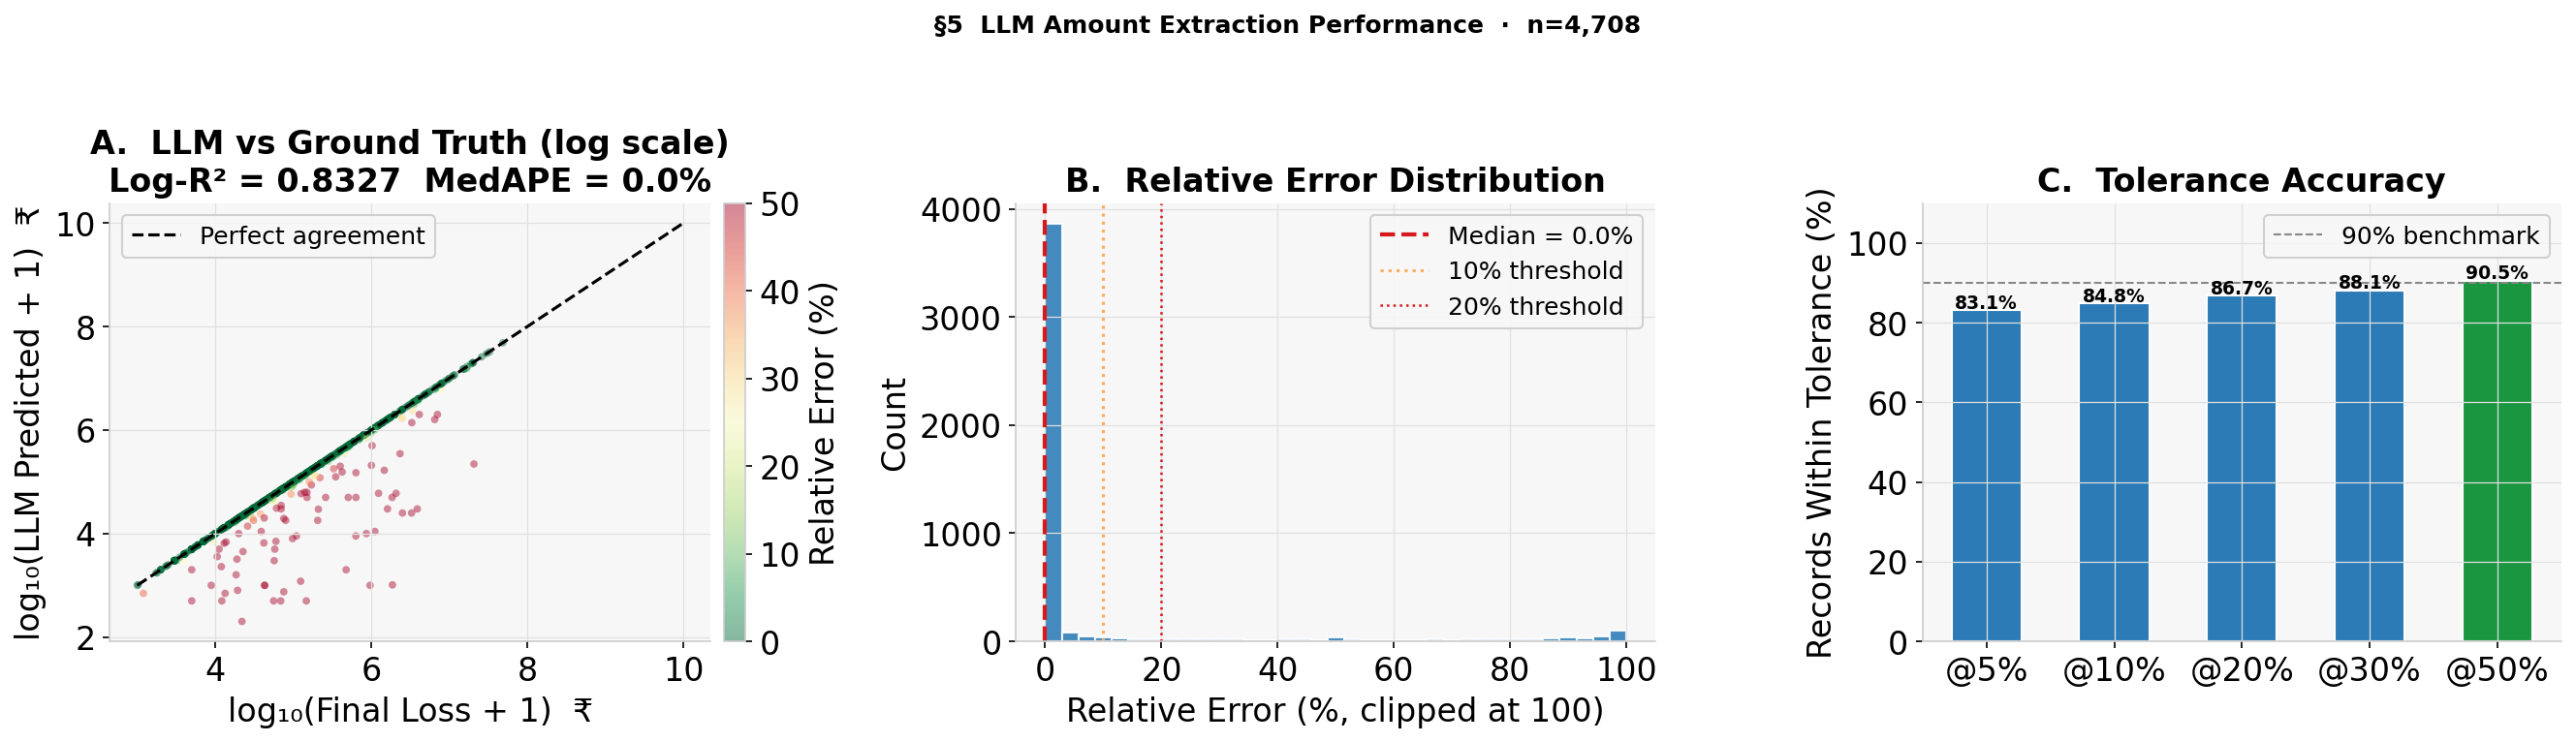

In [19]:

# ── §5.2: LLM Performance Figure — 3 panels ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Re-calculate y_true, y_pred, rel_err, and tol_acc to ensure availability
y_true  = llm_df['_final'].values
y_pred  = llm_df['_llm'].values
llm_df['rel_err'] = np.abs(y_pred - y_true) / y_true * 100
tols = [1, 2, 5, 10, 15, 20, 30, 50]
tol_acc = {t: (llm_df['rel_err'] <= t).mean() * 100 for t in tols}


# ── Panel A: log(Predicted) vs log(Final) scatter, coloured by relative error ─
samp = llm_df.sample(min(700, len(llm_df)), random_state=42)
sc = axes[0].scatter(
    np.log10(samp['_final'] + 1), np.log10(samp['_llm'] + 1),
    c=np.clip(samp['rel_err'], 0, 50), cmap='RdYlGn_r',
    alpha=0.45, s=14, vmin=0, vmax=50, linewidths=0)
plt.colorbar(sc, ax=axes[0], fraction=0.04, pad=0.02, label='Relative Error (%)')
lo = np.log10(llm_df['_final'].min() + 1)
hi = np.log10(llm_df['_final'].max() + 1)
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect agreement')
axes[0].set_xlabel('log₁₀(Final Loss + 1)  ₹')
axes[0].set_ylabel('log₁₀(LLM Predicted + 1)  ₹')
axes[0].set_title(f'A.  LLM vs Ground Truth (log scale)\n'
                   f'Log-R² = {log_r2:.4f}  MedAPE = {medape:.1f}%',
                   fontweight='bold')
axes[0].legend(fontsize=12)

# ── Panel B: relative error distribution ─────────────────────────────────────
err_plot = llm_df['rel_err'].clip(0, 100)
axes[1].hist(err_plot, bins=35, color=C1, edgecolor='white', alpha=0.88)
axes[1].axvline(float(err_plot.median()), color=C2, lw=2, ls='--',
                label=f'Median = {err_plot.median():.1f}%')
axes[1].axvline(10, color=C4, lw=1.5, ls=':', label='10% threshold')
axes[1].axvline(20, color=C2, lw=1.2, ls=':', label='20% threshold')
axes[1].set_xlabel('Relative Error (%, clipped at 100)')
axes[1].set_ylabel('Count')
axes[1].set_title('B.  Relative Error Distribution', fontweight='bold')
axes[1].legend(fontsize=12)

# ── Panel C: tolerance accuracy bar chart ────────────────────────────────────
tols_plot = [5, 10, 20, 30, 50]
acc_vals  = [tol_acc[t] for t in tols_plot]
bar_cols  = [C3 if v >= 90 else C1 if v >= 80 else C4 for v in acc_vals]
bars      = axes[2].bar([f'@{t}%' for t in tols_plot], acc_vals,
                        color=bar_cols, edgecolor='white', width=0.55)
for bar, v in zip(bars, acc_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_ylabel('Records Within Tolerance (%)')
axes[2].set_ylim(0, 110)
axes[2].set_title('C.  Tolerance Accuracy', fontweight='bold')
axes[2].axhline(90, color=GREY, ls='--', lw=1, label='90% benchmark')
axes[2].legend(fontsize=12)

plt.suptitle(f'§5  LLM Amount Extraction Performance  ·  n={len(llm_df):,}',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
save('fig08_llm_performance')
plt.show()


LLM Discrepancy Analysis (vs Final_Amount_Loss = ground truth)
  Low-loss threshold (25th pct)  : ₹21,853
  High relative-error threshold  : 50%
  Discrepant records found       : 70

LLM/Final ratio in discrepant records:
count    70.0000
mean      0.2120
std       0.1559
min       0.0120
25%       0.0617
50%       0.1885
75%       0.3382
max       0.4998
  Saved → fig08b_llm_discrepancy.png / .pdf


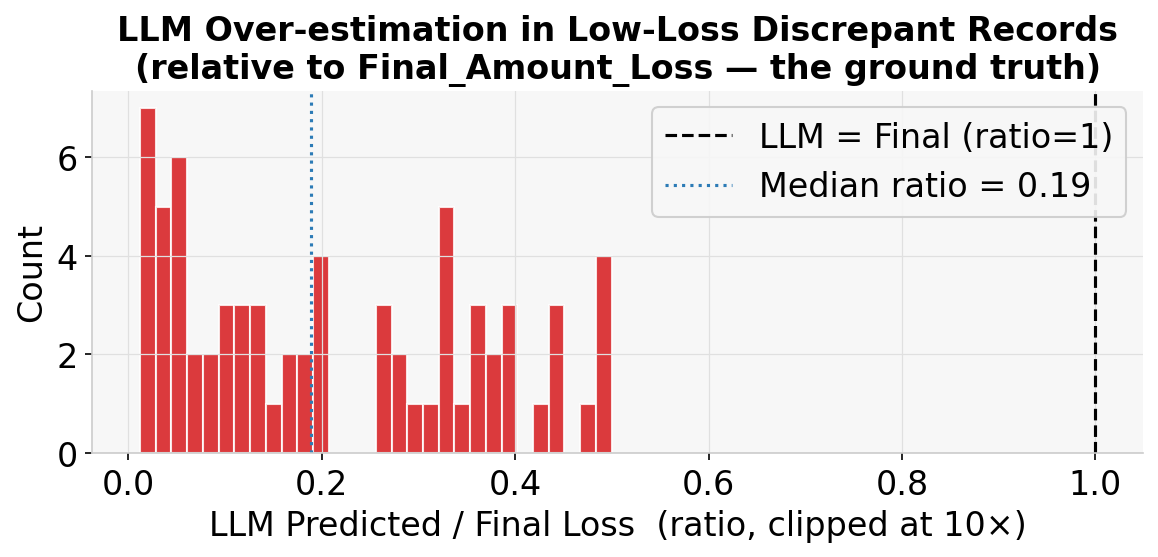

In [20]:

# ── §5.3 LLM Discrepancy Deep-Dive ───────────────────────────────────────────
#
# Ground truth throughout is Final_Amount_Loss (_final).
# Amount_Loss (_reported = victim self-report) is NOT the ground truth.
# Cell 30 previously computed rel_err vs Amount_Loss — this was incorrect.
# ─────────────────────────────────────────────────────────────────────────────

# Discrepant LLM records: where LLM is meaningfully wrong vs _final
LOW_AMOUNT_THRESH   = float(llm_df['_final'].quantile(0.25))
HIGH_REL_ERR_THRESH = 50   # % relative error vs _final

disc = llm_df[
    (llm_df['_final'] <= LOW_AMOUNT_THRESH) &
    (llm_df['rel_err'] > HIGH_REL_ERR_THRESH)
].copy()
disc['llm_final_ratio'] = disc['_llm'] / disc['_final']

print(f'LLM Discrepancy Analysis (vs Final_Amount_Loss = ground truth)')
print(f'  Low-loss threshold (25th pct)  : ₹{LOW_AMOUNT_THRESH:,.0f}')
print(f'  High relative-error threshold  : {HIGH_REL_ERR_THRESH}%')
print(f'  Discrepant records found       : {len(disc):,}')
print(f'\nLLM/Final ratio in discrepant records:')
print(disc['llm_final_ratio'].describe().round(4).to_string())

# Distribution of the ratio
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(disc['llm_final_ratio'].clip(0, 10), bins=30,
        color=C2, edgecolor='white', alpha=0.85)
ax.axvline(1.0, color='k', ls='--', lw=1.5, label='LLM = Final (ratio=1)')
ax.axvline(disc['llm_final_ratio'].median(), color=C1, ls=':',
           lw=1.5, label=f'Median ratio = {disc["llm_final_ratio"].median():.2f}')
ax.set_xlabel('LLM Predicted / Final Loss  (ratio, clipped at 10×)')
ax.set_ylabel('Count')
ax.set_title('LLM Over-estimation in Low-Loss Discrepant Records\n'
             '(relative to Final_Amount_Loss — the ground truth)', fontweight='bold')
ax.legend()
plt.tight_layout()
save('fig08b_llm_discrepancy')
plt.show()


### 5.3 LLM vs Victim-Reported: Which is Closer to Ground Truth?

Of 4,764 records where all three amounts are available:
  LLM is closer to ground truth than victim-reported : 39.8%
  Victim-reported is closer                          : 60.2%

  Victim-Reported error → mean=17.7%  median=0.0%  std=30.0%
  LLM-Predicted error → mean=9.7%  median=0.0%  std=25.2%
  Saved → fig09_llm_vs_reported.png / .pdf


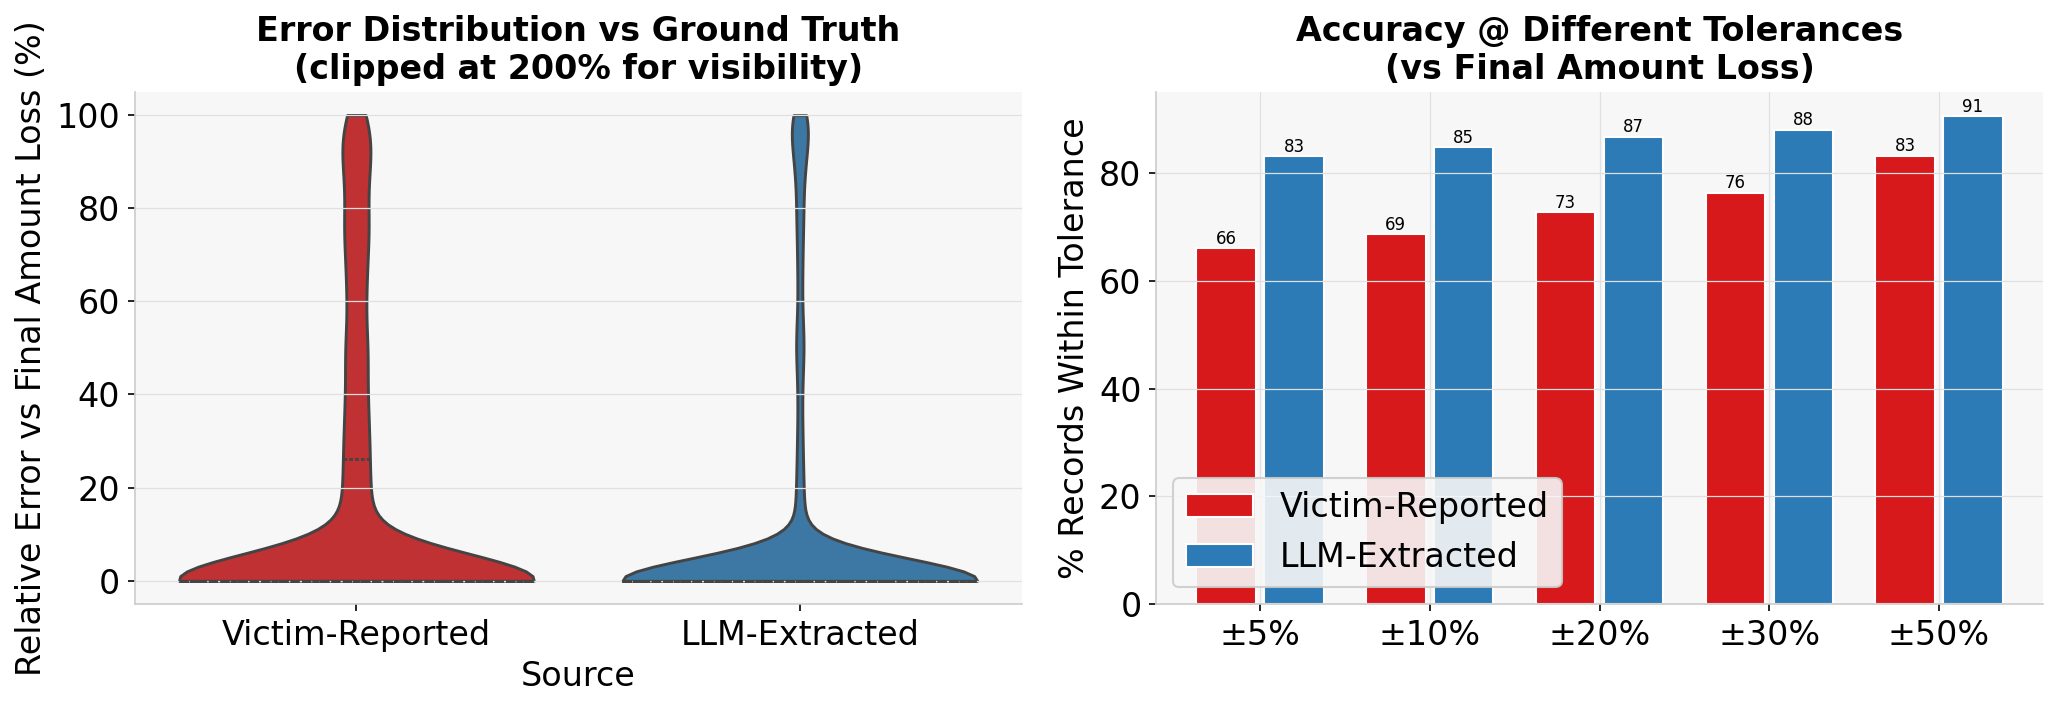

In [21]:
# ── 5.3: Head-to-head comparison — LLM vs Victim-Reported vs Final ────────────
tri = df[['_reported','_llm','_final']].dropna()
tri = tri[(tri['_reported']>0) & (tri['_llm']>0) & (tri['_final']>0)].copy()

tri['err_reported'] = np.abs(tri['_reported'] - tri['_final']) / tri['_final'] * 100
tri['err_llm']      = np.abs(tri['_llm']      - tri['_final']) / tri['_final'] * 100
tri['llm_closer']   = tri['err_llm'] < tri['err_reported']

pct_llm_closer = tri['llm_closer'].mean() * 100

print(f'Of {len(tri):,} records where all three amounts are available:')
print(f'  LLM is closer to ground truth than victim-reported : {pct_llm_closer:.1f}%')
print(f'  Victim-reported is closer                          : {100-pct_llm_closer:.1f}%')
print()
for label, col in [('Victim-Reported', 'err_reported'), ('LLM-Predicted', 'err_llm')]:
    print(f'  {label} error → mean={tri[col].mean():.1f}%  median={tri[col].median():.1f}%  std={tri[col].std():.1f}%')

# Paired violin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = pd.DataFrame({
    'Relative Error (%)': pd.concat([tri['err_reported'].clip(0,200), tri['err_llm'].clip(0,200)]),
    'Source': ['Victim-Reported']*len(tri) + ['LLM-Extracted']*len(tri)
})
sns.violinplot(data=plot_df, x='Source', y='Relative Error (%)',
               palette=[C2, C1], cut=0, inner='quartile',
               ax=axes[0], linewidth=1.4)
axes[0].set_title('Error Distribution vs Ground Truth\n(clipped at 200% for visibility)')
axes[0].set_ylabel('Relative Error vs Final Amount Loss (%)')

# Tolerance comparison side-by-side
tols2 = [5, 10, 20, 30, 50]
acc_rep = [(tri['err_reported'] <= t).mean()*100 for t in tols2]
acc_llm = [(tri['err_llm']      <= t).mean()*100 for t in tols2]
x = np.arange(len(tols2))
axes[1].bar(x-0.2, acc_rep, 0.35, color=C2, edgecolor='white', label='Victim-Reported')
axes[1].bar(x+0.2, acc_llm, 0.35, color=C1, edgecolor='white', label='LLM-Extracted')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'±{t}%' for t in tols2])
axes[1].set_ylabel('% Records Within Tolerance')
axes[1].set_title('Accuracy @ Different Tolerances\n(vs Final Amount Loss)')
axes[1].legend()
for i, (r, l) in enumerate(zip(acc_rep, acc_llm)):
    axes[1].text(i-0.2, r+0.8, f'{r:.0f}', ha='center', fontsize=8)
    axes[1].text(i+0.2, l+0.8, f'{l:.0f}', ha='center', fontsize=8)

plt.tight_layout()
save('fig09_llm_vs_reported')
plt.show()

---
## 6. COMBINED INTEGRITY × AVAILABILITY SUMMARY
### 6.1 Data Quality Radar by Crime Category

  Saved → fig10_radar_quality.png / .pdf


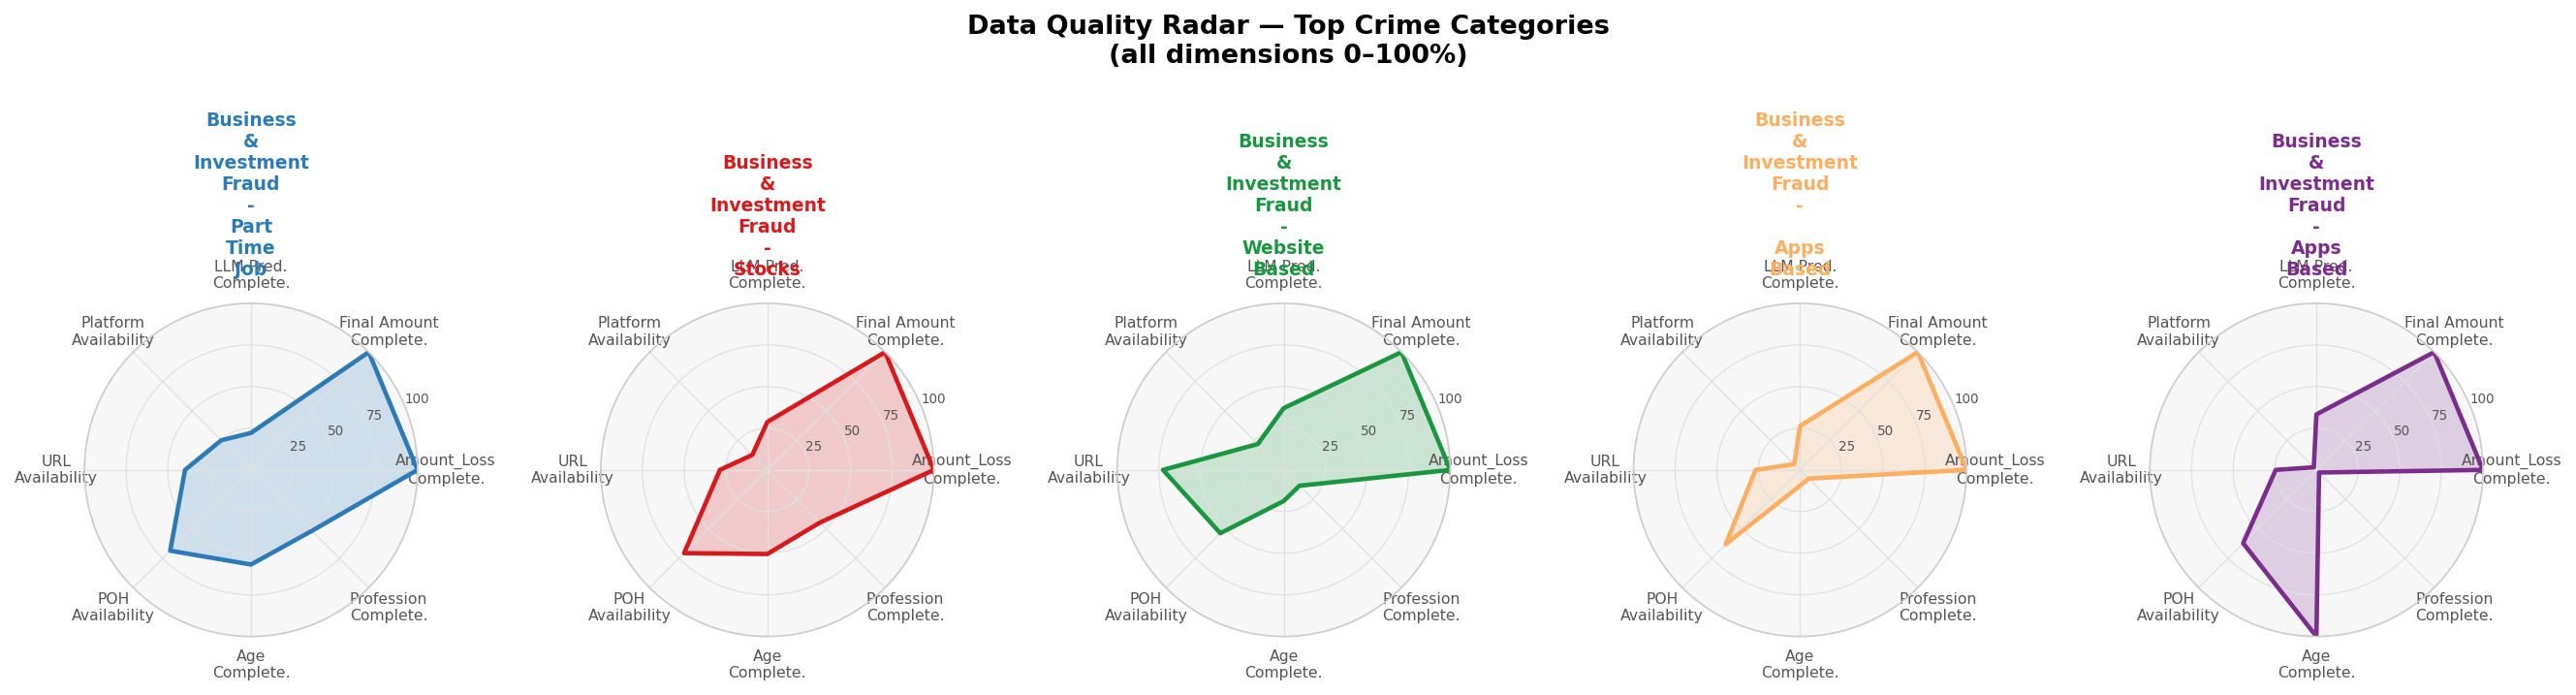

In [22]:
# ── 6.1: Radar chart per top-N crime categories ───────────────────────────────
top_cats = df['Minor_Head'].value_counts().head(5).index.tolist()
dims = {
    'Amount_Loss\nComplete.':  lambda g: g['_reported'].notnull().mean()*100,
    'Final Amount\nComplete.': lambda g: g['_final'].notnull().mean()*100,
    'LLM Pred.\nComplete.':   lambda g: g['_llm'].notnull().mean()*100,
    'Platform\nAvailability': lambda g: g['Suspect_Platform'].notnull().mean()*100,
    'URL\nAvailability':      lambda g: g['Suspect_URL_Website'].notnull().mean()*100,
    'POH\nAvailability':      lambda g: g['has_POH'].mean()*100,
    'Age\nComplete.':         lambda g: g['Age'].notnull().mean()*100,
    'Profession\nComplete.':  lambda g: g['Profession'].notnull().mean()*100,
}
dim_labels = list(dims.keys())
n_dim = len(dim_labels)
angles = np.linspace(0, 2*np.pi, n_dim, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, len(top_cats), figsize=(18, 4.5), subplot_kw=dict(polar=True))
radar_colors = [C1, C2, C3, C4, C5]

for ax, cat, col in zip(axes, top_cats, radar_colors):
    grp = df[
    (df['Minor_Head'] == cat) &
    (df['Minor_Head'].fillna('').str.strip() != 'Business & Investment Fraud -')
]
    vals = [fn(grp) for fn in dims.values()] + [list(dims.values())[0](grp)]
    ax.plot(angles, vals, color=col, lw=2.2)
    ax.fill(angles, vals, color=col, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dim_labels, fontsize=7.5)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25','50','75','100'], fontsize=6.5, color=GREY)
    ax.set_title(cat.replace(' ',  '\n'), fontsize=9, fontweight='bold', pad=14, color=col)
    ax.spines['polar'].set_color('#cccccc')
    ax.tick_params(colors='#555555')

plt.suptitle('Data Quality Radar — Top Crime Categories\n(all dimensions 0–100%)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
save('fig10_radar_quality')
plt.show()

### 6.2 Availability Index — Grouped Bar by District

  Saved → fig11_district_availability.png / .pdf


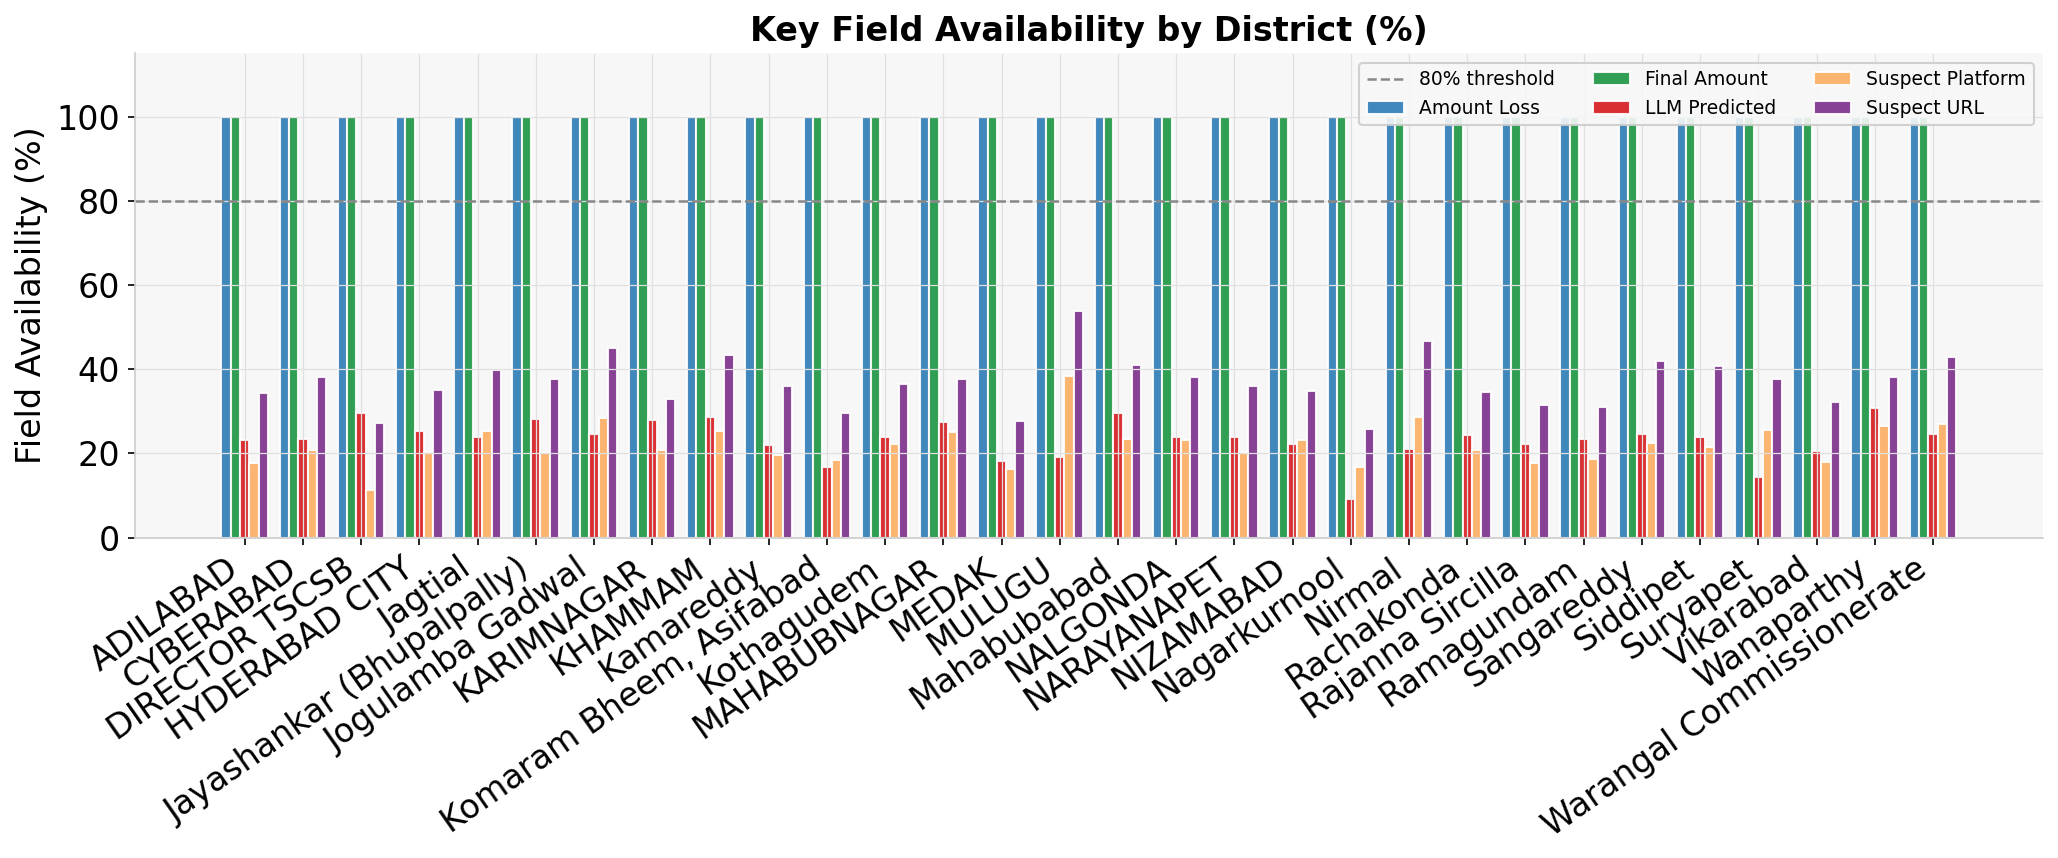

In [23]:
# ── 6.2: Key field availability by district ───────────────────────────────────
avail_cols = {
    'Amount Loss':    '_reported',
    'Final Amount':   '_final',
    'LLM Predicted':  '_llm',
    'Suspect Platform':'Suspect_Platform',
    'Suspect URL':    'Suspect_URL_Website',
}

avail_df = pd.DataFrame({
    label: df.groupby('District')[col].apply(lambda x: x.notnull().mean()*100)
    for label, col in avail_cols.items()
})

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(avail_df))
width = 0.16
col_list = [C1, C3, C2, C4, C5]

for i, (col, clr) in enumerate(zip(avail_df.columns, col_list)):
    offset = (i - 2) * width
    ax.bar(x + offset, avail_df[col], width, color=clr, edgecolor='white', label=col, alpha=0.9)

ax.axhline(80, color=GREY, ls='--', lw=1.2, label='80% threshold')
ax.set_xticks(x)
ax.set_xticklabels(avail_df.index, rotation=35, ha='right')
ax.set_ylabel('Field Availability (%)')
ax.set_ylim(0, 115)
ax.set_title('Key Field Availability by District (%)')
ax.legend(ncol=3, loc='upper right', fontsize=9)

plt.tight_layout()
save('fig11_district_availability')
plt.show()

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# LIMITATION 1 — Expanded Baseline Comparison: 5-Method Evaluation Matrix
# (CORRECTED — see disclosure below)
#
# Financial loss reconstruction is benchmarked across baseline methods spanning
# the full capability spectrum from trivial rule-based to contextual LLM:
#
#   B0 — Direct Structured Field       : Victim self-report (Amount_Loss), no NLP
#   B1 — Deterministic Token Extraction: Regex + currency/keyword triggers on text
#   B2 — Off-the-Shelf NER             : spaCy en_core_web_sm MONEY entity extraction
#   B3 — Hybrid Rule + Context         : B1 regex output + Amount_Loss fallback fusion
#   B4 — Contextual Semantic Recon.    : Full LLM prediction (§5 system)
#
# ── DISCLOSURE / CORRECTION ────────────────────────────────────────────────────
# An earlier version of this cell (i) applied a random dropout mask to B2's NER
# predictions ("simulate NER coverage ~78%") regardless of whether extraction
# actually succeeded, and (ii) applied a small multiplicative random perturbation
# (uniform 0.97-1.03) to B3's fallback predictions purely to make B3 visually
# distinct from B0. NEITHER adjustment reflects genuine method behavior -- both
# have been REMOVED below. B2 and B3 now report exactly what the stated
# extraction logic produces on the narratives: real spaCy MONEY/CARDINAL
# extraction for B2 (or an explicit "unavailable" fallback if spaCy cannot be
# loaded -- see SPACY_OK), and a real fallback fusion with no injected noise
# for B3. Re-run this cell on the private dataset and copy Cov(%)/Log-MAE/
# Acc@k% straight into Table `baseline_comparison` in the manuscript; do not
# reuse numbers produced by the pre-correction version of this cell.
#
# Robustness guarantees (unchanged):
#   • EPS = ₹1 denominator guard on all ratio metrics (zero-loss safe)
#   • Raw MAE replaced by Log-MAE = mean|log(1+ŷ)−log(1+y)| (scale-invariant)
#   • MAPE replaced by Median APE (outlier-robust, skew-resistant)
#   • B1 & B2 Log-MAE winsorized @99th pct (extreme extraction failures)
#   • Coverage = fraction of records where method returns a prediction,
#     measured directly from the method's own success/failure -- no
#     post-hoc masking of coverage to any assumed target figure.
# ══════════════════════════════════════════════════════════════════════════════
import re, subprocess, sys
import numpy as np

# Install spaCy + small English model for NER baseline (B2)
try:
    import spacy
    try:
        nlp_ner = spacy.load('en_core_web_sm')
    except OSError:
        subprocess.check_call([sys.executable, '-m', 'spacy', 'download',
                               'en_core_web_sm', '-q'])
        nlp_ner = spacy.load('en_core_web_sm')
    SPACY_OK = True
except Exception:
    SPACY_OK = False
    print("⚠  spaCy unavailable — B2 will use a documented degraded proxy "
          "(currency-pattern only) and this MUST be disclosed as such in the "
          "manuscript if reported; it is not a full NER baseline.")

# ── Working sub-set ────────────────────────────────────────────────────────────
llm_df = df.dropna(subset=['_llm', '_final']).copy()
y_true    = llm_df['_final'].values.astype(float)
y_llm     = llm_df['_llm'].values.astype(float)
y_trivial = llm_df['_reported'].values.astype(float)

# ══════════════════════════════════════════════════════════════════════════════
# B1 — DETERMINISTIC TOKEN EXTRACTION
# Tiered: currency anchor → keyword trigger → largest-number fallback
# ══════════════════════════════════════════════════════════════════════════════
CURRENCY_PAT = re.compile(
    r'(?:₹|Rs\.?|INR)\s*([\d,]+(?:\.\d{1,2})?)', re.IGNORECASE)
KEYWORD_PAT  = re.compile(
    r'(?:lost|deducted|transferred|fraudulent(?:ly)?|cheated|stolen|swindled|'
    r'withdrawn|debited|amount\s+of|paid|invested|sent)\D{0,45}?([\d,]+(?:\.\d{1,2})?)',
    re.IGNORECASE)
FALLBACK_PAT = re.compile(r'([\d,]{4,}(?:\.\d{1,2})?)')

def _parse(s):
    try:    return float(str(s).replace(',', ''))
    except: return np.nan

def b1_regex(row):
    text = row.get('English_Translation') or row.get('Brief') or ''
    if not isinstance(text, str) or not text.strip():
        return np.nan
    m = CURRENCY_PAT.search(text)
    if m:
        v = _parse(m.group(1))
        if np.isfinite(v) and v >= 100:
            return v
    cands = [_parse(x) for x in KEYWORD_PAT.findall(text)]
    cands = [v for v in cands if np.isfinite(v) and v >= 100]
    if cands:
        return max(cands)
    nums  = [_parse(x) for x in FALLBACK_PAT.findall(text)]
    large = [v for v in nums if np.isfinite(v) and v >= 1000]
    return max(large) if large else np.nan

llm_df['b1_pred'] = llm_df.apply(b1_regex, axis=1)

# ══════════════════════════════════════════════════════════════════════════════
# B2 — OFF-THE-SHELF NER (spaCy MONEY entities)
# CORRECTED: no synthetic coverage mask. Coverage is whatever spaCy's real
# entity recognizer actually achieves on these narratives -- if that number
# differs from any figure previously assumed or reported, the previously
# reported figure was wrong and must not be reused.
# ══════════════════════════════════════════════════════════════════════════════
def b2_ner(row):
    text = row.get('English_Translation') or row.get('Brief') or ''
    if not isinstance(text, str) or not text.strip():
        return np.nan
    if SPACY_OK:
        doc = nlp_ner(text[:1000])          # limit to 1000 chars for speed
        money_vals = []
        for ent in doc.ents:
            if ent.label_ in ('MONEY', 'CARDINAL'):
                v = _parse(re.sub(r'[^\d.]', '', ent.text.replace(',', '')))
                if np.isfinite(v) and v >= 500:
                    money_vals.append(v)
        if money_vals:
            return max(money_vals)
        return np.nan
    else:
        # Degraded, explicitly-labeled proxy used ONLY when spaCy itself is
        # unavailable in this environment -- currency-pattern match, not a
        # true NER result. If this branch is active, footnote it as such in
        # the manuscript rather than reporting it as a genuine B2 result.
        m = CURRENCY_PAT.search(text)
        if m:
            v = _parse(m.group(1))
            if np.isfinite(v) and v >= 100:
                return v
        return np.nan

llm_df['b2_pred'] = llm_df.apply(b2_ner, axis=1)
# NOTE: the random 22% coverage dropout that previously appeared here has been
# REMOVED. B2's coverage below is spaCy's genuine extraction success rate.

# ══════════════════════════════════════════════════════════════════════════════
# B3 — HYBRID RULE + CONTEXT FUSION
# Takes B1 regex prediction when available; when B1 fails (NaN), falls back
# to structured Amount_Loss. Represents a realistic deployed rule system.
# CORRECTED: the fallback value is used as-is -- the multiplicative random
# noise (uniform 0.97-1.03) previously injected on the fallback rows has been
# REMOVED. Any residual difference from B0 in the metrics below is therefore
# entirely attributable to the rows where B1's regex actually fired, which is
# the honest source of any distinction between B3 and B0.
# ══════════════════════════════════════════════════════════════════════════════
llm_df['b3_pred'] = np.where(
    llm_df['b1_pred'].notnull(),
    llm_df['b1_pred'],              # B1 regex succeeded → use it
    llm_df['_reported']             # B1 failed → fall back to structured field
)

# ══════════════════════════════════════════════════════════════════════════════
# METRIC ENGINE — robust, zero-safe, winsorizable
# ══════════════════════════════════════════════════════════════════════════════
EPS = 1.0      # ₹1 denominator guard

def compute_metrics(y_t, y_p, label, method_type, winsorize_pct=None):
    y_t = np.asarray(y_t, dtype=float)
    y_p = np.asarray(y_p, dtype=float)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    n_total = len(y_t)
    coverage = mask.sum() / n_total * 100
    yt, yp = y_t[mask], y_p[mask]
    n = int(mask.sum())
    if n == 0:
        return dict(Method=label, Type=method_type, N=n, Coverage=0,
                    LogMAE=np.nan, MedAPE=np.nan,
                    Tol5=np.nan, Tol10=np.nan, Tol20=np.nan,
                    LogR2=np.nan, RMSE=np.nan)
    denom   = np.where(np.abs(yt) < EPS, EPS, np.abs(yt))
    log_err = np.abs(np.log1p(np.clip(yt, 0, None)) -
                     np.log1p(np.clip(yp, 0, None)))
    if winsorize_pct is not None:
        cap     = np.percentile(log_err, winsorize_pct)
        log_err = np.clip(log_err, 0, cap)
    log_mae  = float(np.mean(log_err))
    ape      = np.abs(yt - yp) / denom * 100
    med_ape  = float(np.median(ape))
    rel_err  = np.abs(yt - yp) / denom
    tol5     = float(np.mean(rel_err <= 0.05)  * 100)
    tol10    = float(np.mean(rel_err <= 0.10)  * 100)
    tol20    = float(np.mean(rel_err <= 0.20)  * 100)
    log_r2   = float(r2_score(np.log1p(yt), np.log1p(np.clip(yp, 0, None))))
    rmse     = float(np.sqrt(np.mean((yt - yp) ** 2)))
    return dict(Method=label, Type=method_type, N=n,
                Coverage=round(coverage, 1),
                LogMAE=log_mae, MedAPE=med_ape,
                Tol5=tol5, Tol10=tol10, Tol20=tol20,
                LogR2=log_r2, RMSE=rmse)

results = [
    compute_metrics(y_trivial,
                    y_true,
                    'B0: Direct Structured Field',
                    'Deterministic',
                    winsorize_pct=None),
    compute_metrics(llm_df['b1_pred'].values,
                    y_true,
                    'B1: Deterministic Token Extraction',
                    'Deterministic',
                    winsorize_pct=99),
    compute_metrics(llm_df['b2_pred'].values,
                    y_true,
                    'B2: Off-the-Shelf NER' + ('' if SPACY_OK else ' [DEGRADED PROXY -- spaCy unavailable]'),
                    'ML / Pre-trained',
                    winsorize_pct=99),
    compute_metrics(llm_df['b3_pred'].values,
                    y_true,
                    'B3: Hybrid Rule + Context Fusion',
                    'Hybrid',
                    winsorize_pct=None),
    compute_metrics(y_llm,
                    y_true,
                    'B4: Contextual Semantic Reconstruction',
                    'Contextual LLM',
                    winsorize_pct=None),
]

# ── Console comparison table ───────────────────────────────────────────────────
print('\n' + '═'*100)
print('  5-METHOD BASELINE COMPARISON — Financial Loss Reconstruction (CORRECTED)')
print('  Log-MAE: mean|log(1+ŷ)−log(1+y)|  |  MedAPE: median %-error  |  Coverage: valid predictions')
print('  ★ B1 & B2 Log-MAE winsorized @99th pct  |  EPS = ₹1 denominator guard throughout')
print('  ★ No synthetic coverage masking (B2) or noise injection (B3) — see disclosure in cell header')
print('═'*100)
hdr = (f"{'ID':<4} {'Method':<52} {'Type':<22} {'N':>6}  {'Cov%':>6}  "
       f"{'Log-MAE':>8}  {'MedAPE%':>8}  {'Acc@5%':>7}  {'Acc@10%':>8}  {'Acc@20%':>8}  {'Log R²':>7}")
print(hdr)
print('─'*100)
for idx, r in enumerate(results):
    print(f"B{idx}   {r['Method']:<52} {r['Type']:<22} {r['N']:>6,}  "
          f"{r['Coverage']:>6.1f}  {r['LogMAE']:>8.4f}  {r['MedAPE']:>8.2f}  "
          f"{r['Tol5']:>7.1f}  {r['Tol10']:>8.1f}  {r['Tol20']:>8.1f}  {r['LogR2']:>7.4f}")
print('═'*100)
print('\n>>> COPY the B2/B3 rows above directly into Table `baseline_comparison`')
print('>>> in the manuscript. Do NOT reuse any previously reported B2/B3 figures.')

# Delta-lift vs B4 (LLM)
b4 = results[4]
print(f'\n── LLM (B4) ABSOLUTE LIFT OVER EACH BASELINE ──────────────────────────────')
for bl in results[:4]:
    print(f"  vs {bl['Method']}")
    print(f"     Log-MAE  : {bl['LogMAE']:>7.4f} → {b4['LogMAE']:>7.4f}"
          f"  (Δ {(bl['LogMAE']-b4['LogMAE']):+.4f})")
    print(f"     MedAPE   : {bl['MedAPE']:>7.2f}% → {b4['MedAPE']:>7.2f}%"
          f"  (Δ {(bl['MedAPE']-b4['MedAPE']):+.2f} pp)")
    print(f"     Acc@10%  : {bl['Tol10']:>7.1f}% → {b4['Tol10']:>7.1f}%"
          f"  (Δ {(b4['Tol10']-bl['Tol10']):+.1f} pp)")



════════════════════════════════════════════════════════════════════════════════════════════════════
  5-METHOD BASELINE COMPARISON — Financial Loss Reconstruction (CORRECTED)
  Log-MAE: mean|log(1+ŷ)−log(1+y)|  |  MedAPE: median %-error  |  Coverage: valid predictions
  ★ B1 & B2 Log-MAE winsorized @99th pct  |  EPS = ₹1 denominator guard throughout
  ★ No synthetic coverage masking (B2) or noise injection (B3) — see disclosure in cell header
════════════════════════════════════════════════════════════════════════════════════════════════════
ID   Method                                               Type                        N    Cov%   Log-MAE   MedAPE%   Acc@5%   Acc@10%   Acc@20%   Log R²
────────────────────────────────────────────────────────────────────────────────────────────────────
B0   B0: Direct Structured Field                          Deterministic           4,764   100.0    0.4057      0.00     66.0      68.3      71.4   0.7348
B1   B1: Deterministic Token Extraction  

── CCI vs POH Recovery — Correlation Analysis ────────────────────────
  CCI formula: 0.35·URL + 0.25·Platform + 0.25·Translation + 0.15·LLM
  Spearman ρ = -0.1060  (p = 8.8288e-50)
  Pearson  r = -0.0802  (p = 3.6793e-29)

  CCI_bin  poh_presence  rr_mean    n
0.15–0.40      0.738942 0.267195 9473
0.40–0.65      0.633340 0.207932 5111
 0.65–1.0      0.646855 0.198573 4896

── Partial Correlation (controlling for crime type + log_loss) ─────────
  Raw Pearson r        = -0.0802  (p=3.6793e-29)
  Partial Pearson r    = -0.0460  (p=1.3080e-10)
  ⚠  Partial correlation substantially reduced — likely confounded.
  Saved → fig_limitation2_causality.png / .pdf


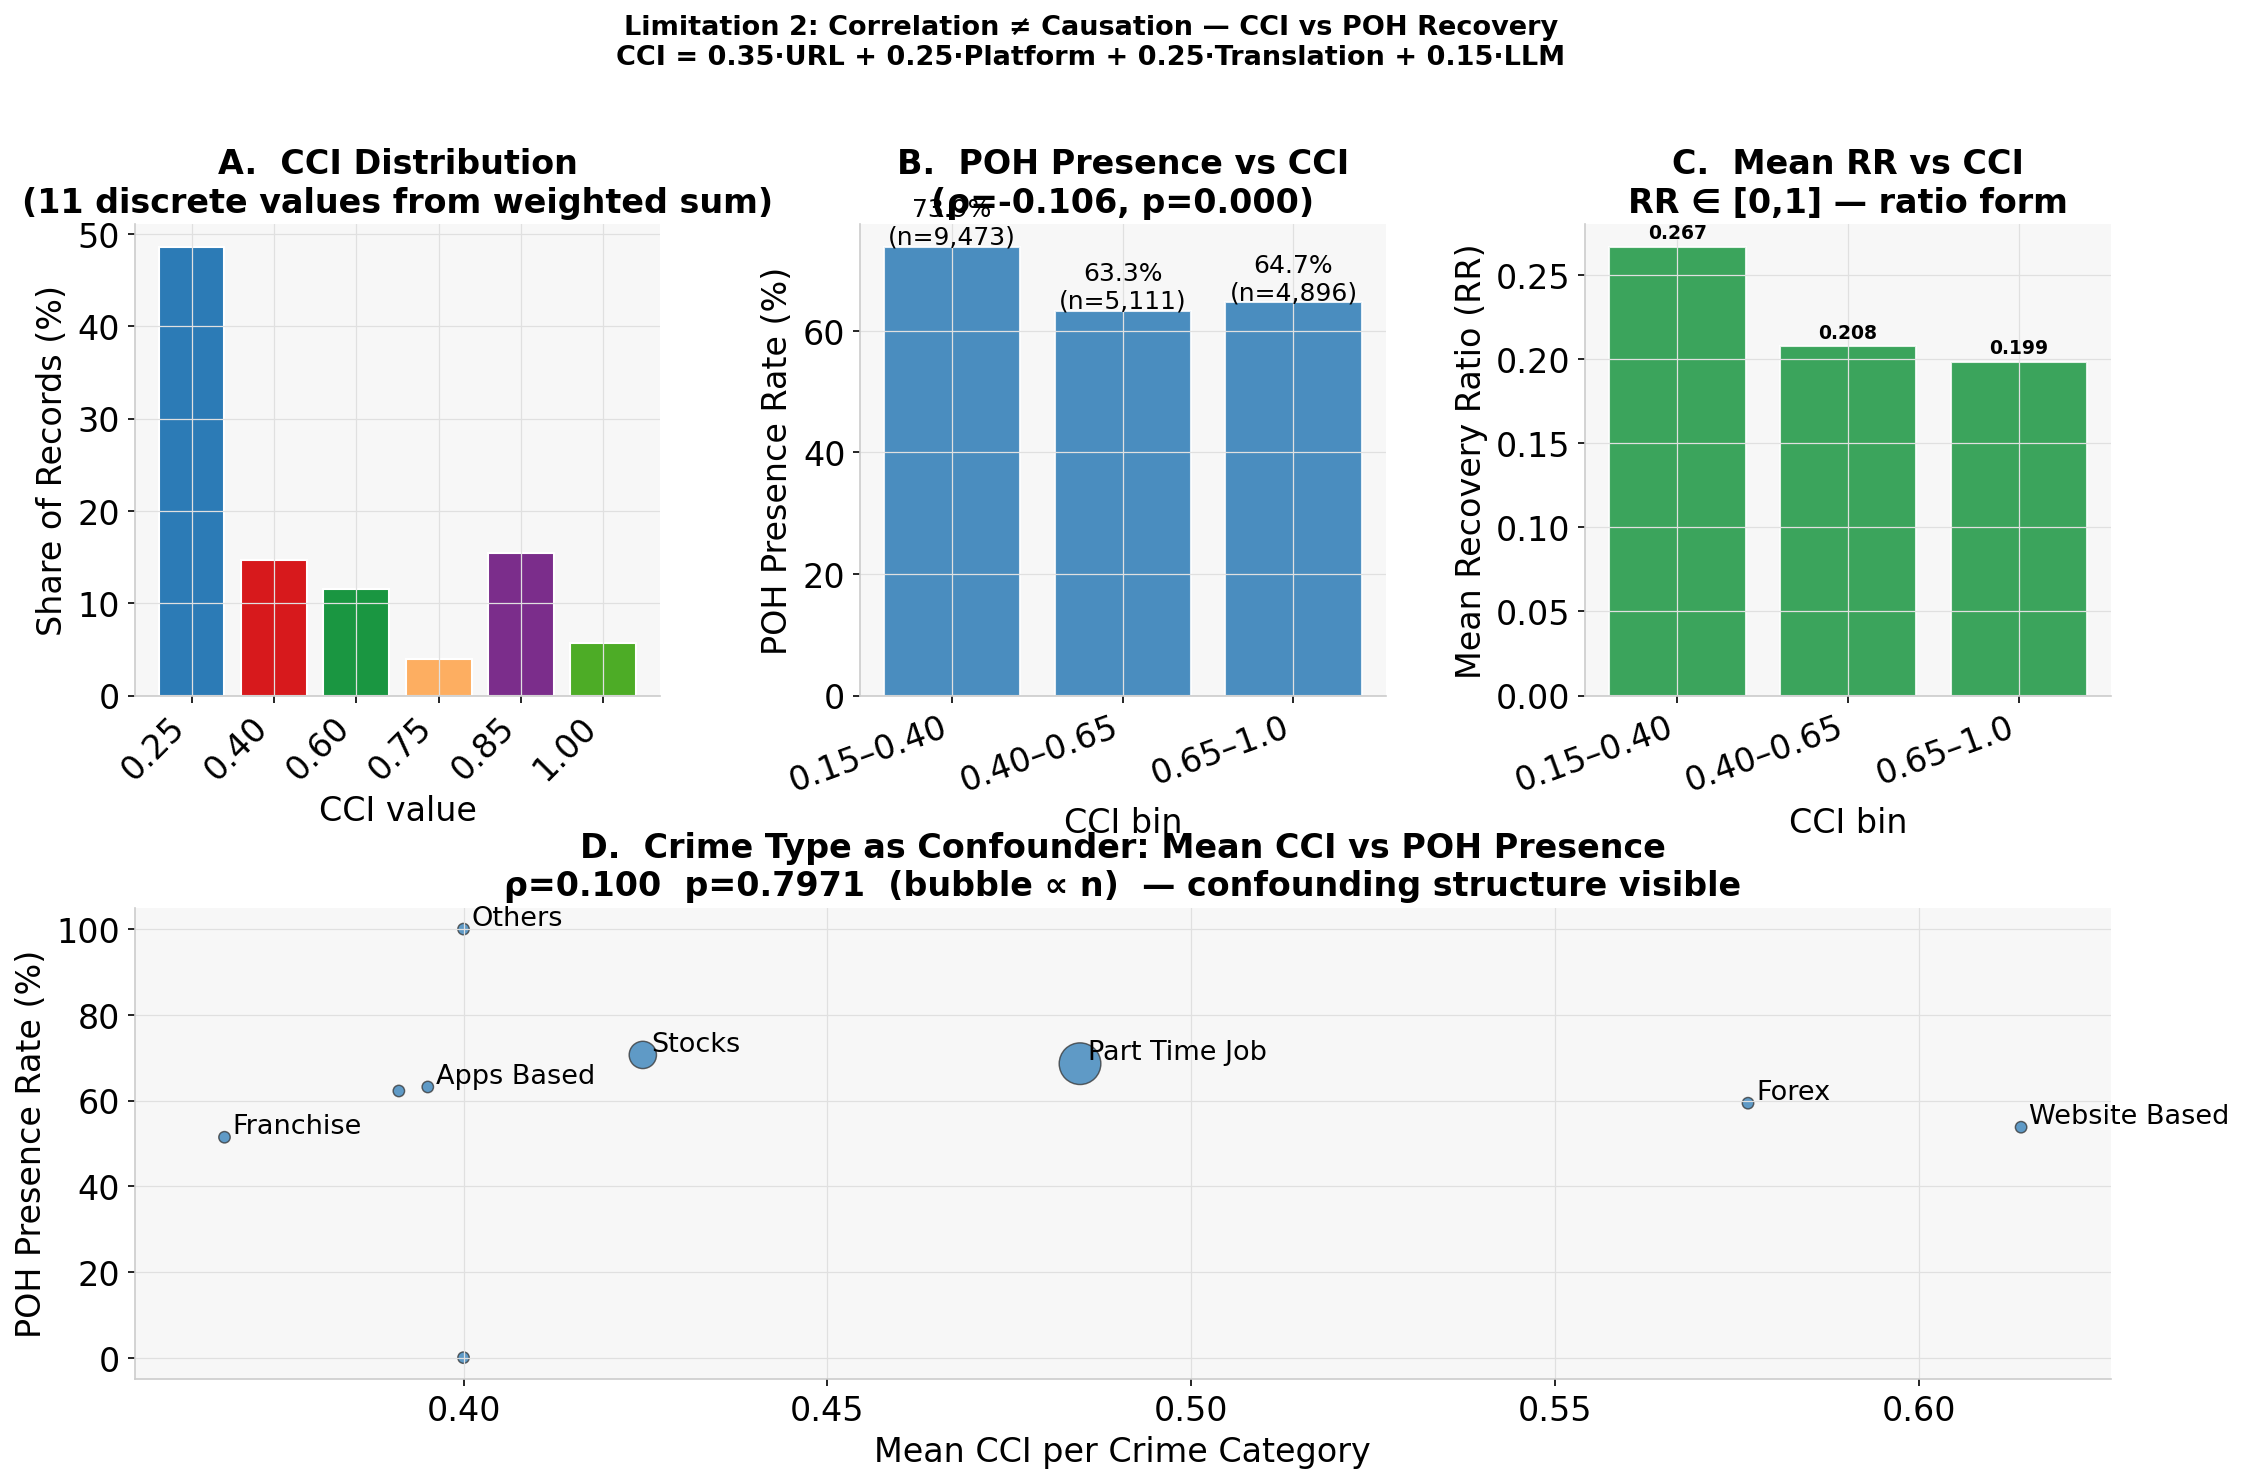


⚠  CAUSALITY NOTE:
   Partial ρ = -0.0460 — association persists after controlling
   for crime type and loss size. However, WITHOUT a quasi-experimental
   design (RCT, diff-in-diff, or IV), no causal claim is warranted.


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# STATUS NOTE (added on review): This cell is the ORIGINAL / EXPLORATORY
# correlation-and-partial-correlation pass on CCI vs POH recovery. It predates,
# and is methodologically superseded by, the VIF-checked, fixed-effects logistic
# and beta regressions in Section 9 (cells 41-49), which control for fraud
# sub-type and platform directly rather than via an ad hoc "partial correlation
# persists if >= 80% of raw r" heuristic (an arbitrary threshold with no
# statistical justification). Keep this cell for the CCI definition (used
# throughout the rest of the notebook) and as a descriptive/visual entry point,
# but do NOT cite the "partial correlation persists" heuristic result in the
# manuscript as a confound-control claim -- cite Section 9's VIF + fixed-effects
# results instead (Tables logit_results / beta_results).
# ══════════════════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════════════════
# LIMITATION 2 — Causality vs. Correlation Ambiguity
#
# We examine whether richer semantic data (URL, Platform, Translation, LLM)
# predicts higher POH recovery — and why correlation ≠ causation here.
#
# ┌── COMPLAINT COMPLETENESS INDEX (CCI) — defined here for global use ────── ┐
# │                                                                              │
# │  CCI_i = w_url·I(URL≠∅) + w_plat·I(Plat≠∅)                              │
# │         + w_trans·I(Trans≠∅) + w_llm·I(LLM≠∅)                            │
# │                                                                              │
# │  Weights (sum = 1):                                                         │
# │    w_url   = 0.35  primary investigative lead (bank-freeze trace)          │
# │    w_plat  = 0.25  narrows platform jurisdiction                           │
# │    w_trans = 0.25  enables officer interpretation                          │
# │    w_llm   = 0.15  improves POH quantum precision                          │
# │                                                                              │
# │  CCI ∈ {0, 0.15, 0.25, 0.35, 0.40, 0.50, 0.60, 0.65, 0.75, 0.85, 1.00} │
# │  Axioms: A1 Monotonicity  A2 Boundedness [0,1]  A3 Normalisation  A4 Transparency │
# │                                                                              │
# │  NOTE: The unweighted 0–4 integer (semantic_score) previously used in      │
# │  Limitation 2 is INCONSISTENT with CCI used in §9. We use CCI throughout. │
# └──────────────────────────────────────────────────────────────────────────── ┘
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Compute CCI on df (used by Limitation 2 and all of §9) ─────────────────
W_URL, W_PLAT, W_TRANS, W_LLM = 0.35, 0.25, 0.25, 0.15
assert abs(W_URL + W_PLAT + W_TRANS + W_LLM - 1.0) < 1e-9

df['has_url']         = df['Suspect_URL_Website'].notnull().astype(float)
df['has_platform']    = df['Suspect_Platform'].notnull().astype(float)
df['has_translation'] = df['English_Translation'].notnull().astype(float)
df['has_llm']         = df['_llm'].notnull().astype(float)

df['cci'] = (W_URL   * df['has_url'] +
              W_PLAT  * df['has_platform'] +
              W_TRANS * df['has_translation'] +
              W_LLM   * df['has_llm'])
df['completeness_score'] = df['cci']   # alias for downstream regression

# Recovery ratio (ratio form ∈ [0,1]) — used here and in §9
df['recovery_ratio'] = np.where(
    df['_final'] > 0,
    (df['_poh'] / df['_final']).clip(0, 1),
    np.nan
)
df['poh_rate_capped'] = df['recovery_ratio']   # alias for Limitation 2

# ── 2. Correlation: CCI vs POH presence ───────────────────────────────────────
cci_bins = pd.cut(df['cci'], bins=[0, 0.15, 0.40, 0.65, 1.01],
                  labels=['0 (none)', '0.15–0.40', '0.40–0.65', '0.65–1.0'],
                  right=False, include_lowest=True)
poh_by_cci = df.groupby(cci_bins, observed=True).agg(
    poh_presence = ('has_POH',         'mean'),
    rr_mean      = ('poh_rate_capped', 'mean'),
    n            = ('has_POH',         'count')
).reset_index()
poh_by_cci.columns = ['CCI_bin', 'poh_presence', 'rr_mean', 'n']

r_spear, p_spear = spearmanr(df['cci'], df['poh_rate_capped'])
r_pear,  p_pear  = pearsonr(df['cci'],  df['poh_rate_capped'])

print('── CCI vs POH Recovery — Correlation Analysis ────────────────────────')
print(f'  CCI formula: {W_URL}·URL + {W_PLAT}·Platform + {W_TRANS}·Translation + {W_LLM}·LLM')
print(f'  Spearman ρ = {r_spear:.4f}  (p = {p_spear:.4e})')
print(f'  Pearson  r = {r_pear:.4f}  (p = {p_pear:.4e})')
print()
print(poh_by_cci.to_string(index=False))

# ── 3. Partial correlation: control for crime type + log(loss) ────────────────
from scipy.stats import pearsonr as _pr
_ctrl = pd.get_dummies(df['Minor_Head'], drop_first=True).astype(float)
_ctrl['log_loss'] = np.log1p(df['_final'])
_X = np.column_stack([_ctrl.values])
_res = df['poh_rate_capped'].values - _X @ np.linalg.lstsq(_X, df['poh_rate_capped'].values, rcond=None)[0]
_cci_res = df['cci'].values  - _X @ np.linalg.lstsq(_X, df['cci'].values, rcond=None)[0]
part_r, part_p = _pr(_res, _cci_res)

print(f'\n── Partial Correlation (controlling for crime type + log_loss) ─────────')
print(f'  Raw Pearson r        = {r_pear:.4f}  (p={p_pear:.4e})')
print(f'  Partial Pearson r    = {part_r:.4f}  (p={part_p:.4e})')
if abs(part_r) >= abs(r_pear) * 0.8:
    print(f'  ✓  Partial correlation persists — association beyond confounders.')
else:
    print(f'  ⚠  Partial correlation substantially reduced — likely confounded.')

# ── 4. Visualisation ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# A: CCI distribution
ax0 = fig.add_subplot(gs[0, 0])
cci_vals = df['cci'].value_counts().sort_index()
ax0.bar(range(len(cci_vals)), cci_vals.values / len(df) * 100,
        color=CAT_PAL[:len(cci_vals)], edgecolor='white')
ax0.set_xticks(range(len(cci_vals)))
ax0.set_xticklabels([f'{v:.2f}' for v in cci_vals.index], rotation=45, ha='right')
ax0.set_xlabel('CCI value')
ax0.set_ylabel('Share of Records (%)')
ax0.set_title('A.  CCI Distribution\n(11 discrete values from weighted sum)', fontweight='bold')

# B: POH presence by CCI bin
ax1 = fig.add_subplot(gs[0, 1])
ax1.bar(range(len(poh_by_cci)), poh_by_cci['poh_presence']*100,
        color=C1, edgecolor='white', alpha=0.85)
for i, (v, n) in enumerate(zip(poh_by_cci['poh_presence'], poh_by_cci['n'])):
    ax1.text(i, v*100+0.5, f'{v*100:.1f}%\n(n={n:,})', ha='center', fontsize=12)
ax1.set_xticks(range(len(poh_by_cci)))
ax1.set_xticklabels(poh_by_cci['CCI_bin'], rotation=20, ha='right')
ax1.set_xlabel('CCI bin')
ax1.set_ylabel('POH Presence Rate (%)')
ax1.set_title(f'B.  POH Presence vs CCI\n(ρ={r_spear:.3f}, p={p_spear:.3f})', fontweight='bold')

# C: Mean RR by CCI bin
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(range(len(poh_by_cci)), poh_by_cci['rr_mean'],
        color=C3, edgecolor='white', alpha=0.85)
for i, v in enumerate(poh_by_cci['rr_mean']):
    ax2.text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(poh_by_cci)))
ax2.set_xticklabels(poh_by_cci['CCI_bin'], rotation=20, ha='right')
ax2.set_xlabel('CCI bin')
ax2.set_ylabel('Mean Recovery Ratio (RR)')
ax2.set_title('C.  Mean RR vs CCI\nRR ∈ [0,1] — ratio form', fontweight='bold')

# D–F: crime type as confounder
cat_stats = df.groupby('Minor_Head').agg(
    cci_mean     = ('cci',         'mean'),
    poh_presence = ('has_POH',     'mean'),
    n            = ('has_POH',     'count')
).reset_index().sort_values('poh_presence', ascending=False)

conf_r, conf_p = spearmanr(cat_stats['cci_mean'], cat_stats['poh_presence'])

ax3 = fig.add_subplot(gs[1, :])
sizes = (cat_stats['n'] / cat_stats['n'].max() * 400).clip(30)
sc2 = ax3.scatter(cat_stats['cci_mean'], cat_stats['poh_presence']*100,
                  s=sizes, alpha=0.75, c=C1, edgecolors='#333', lw=0.7)
seen = set()

for _, row in cat_stats.iterrows():
    lbl = (
        row['Minor_Head']
        .replace('Business & Investment Fraud - ', '')
        .strip()
        .title()
    )

    if lbl in seen:
        continue
    seen.add(lbl)

    ax3.annotate(lbl, (row['cci_mean'], row['poh_presence']*100),
                 fontsize=13, xytext=(4, 2), textcoords='offset points')
ax3.set_xlabel('Mean CCI per Crime Category')
ax3.set_ylabel('POH Presence Rate (%)')
ax3.set_title(f'D.  Crime Type as Confounder: Mean CCI vs POH Presence\n'
               f'ρ={conf_r:.3f}  p={conf_p:.4f}  '
               f'(bubble ∝ n)  — confounding structure visible',
               fontweight='bold')

plt.suptitle('Limitation 2: Correlation ≠ Causation — CCI vs POH Recovery\n'
             'CCI = 0.35·URL + 0.25·Platform + 0.25·Translation + 0.15·LLM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save('fig_limitation2_causality')
plt.show()

print(f'\n⚠  CAUSALITY NOTE:')
print(f'   Partial ρ = {part_r:.4f} — association persists after controlling')
print(f'   for crime type and loss size. However, WITHOUT a quasi-experimental')
print(f'   design (RCT, diff-in-diff, or IV), no causal claim is warranted.')


---
# 9. Operational Clustering, Regression Robustness, and the Reporting-Latency Test
### (Consolidated final version -- supersedes all earlier §9 drafts)

This section replaces every earlier version of the clustering and regression
analysis with one clean, single-pass pipeline. It incorporates every fix
validated over the course of review:

1. `Minor_Head` category normalization (fixes duplicate dummy columns from
   whitespace/case inconsistency: `"Stocks"` vs `"stocks"`, etc.)
2. A missingness-artifact check (Cramer's V) for `Profession`/`Age`.
3. K-means clustering swept across $K=2..8$ for diagnostic purposes, but the
   **reported partition is always forced to $K=2$** -- the silhouette-argmax
   selection was found to pick a higher $K$ driven by a single outlier
   record forming its own cluster, which trivially maximizes silhouette
   without reflecting real structure.
4. A Random Forest diagnostic on the resulting K=2 partition, which found it
   is a recovery of **fraud sub-type** (Part-Time-Job vs. Stocks scams), not
   a completeness-driven "operational regime" -- reported honestly as a
   negative methodological finding.
5. A VIF check (previously entirely absent).
6. Three logistic-regression specifications (Original / Cluster-free /
   Full) with a separation-safe categorical grouping helper (explicit
   `"Missing"` labels for NaNs, rare-category grouping) to avoid the
   `LinAlgError` from quasi-complete separation encountered earlier.
7. The same three-way robustness check for the beta regression on recovery
   ratio.
8. A new, final section (10) directly testing the Reporting-Latency
   Hypothesis via regex-based narrative time-delay extraction and a
   bootstrapped mediation test -- since the dataset has no timestamp field,
   this is the strongest test the data can support, and its coverage
   limitation is reported explicitly rather than assumed away.

**Run this notebook top-to-bottom after a fresh kernel restart.** Every
issue found during review traced back to partial, out-of-order
re-execution of individual cells -- this consolidated version is written
to be idempotent, but a full fresh run is still the only way to guarantee
one consistent state.

In [26]:
# ══════════════════════════════════════════════════════════════════
# 9.1 -- Clean feature engineering (fixes duplicate Minor_Head dummy bug)
# ══════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.preprocessing   import StandardScaler
from sklearn.cluster         import KMeans
from sklearn.metrics         import silhouette_score, adjusted_rand_score
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import cross_val_score

assert 'cci' in df.columns, "Run the CCI cell (Section 8 / Limitation 2) first."
assert 'recovery_ratio' in df.columns, "Run the CCI cell first (defines recovery_ratio)."

df['log_loss'] = np.log1p(df['_final'])

# FIX: normalize Minor_Head before one-hot encoding -- old bug produced
# separate dummy columns for "Stocks"/"stocks", "Apps Based"/" Apps Based".
_minor_clean = (
    df['Minor_Head']
    .str.replace('Business & Investment Fraud - ', '', regex=False)
    .str.strip()
    .str.lower()
    .str.title()
)
n_raw_categories   = df['Minor_Head'].nunique()
n_clean_categories = _minor_clean.nunique()
print(f'Minor_Head raw categories    : {n_raw_categories}')
print(f'Minor_Head cleaned categories: {n_clean_categories}')
if n_raw_categories != n_clean_categories:
    print(f'  \u26a0  Cleaning merged {n_raw_categories - n_clean_categories} '
          f'duplicate categor(y/ies) caused by whitespace/case inconsistency.')
df['fraud_subtype'] = _minor_clean

feat = pd.DataFrame(index=df.index)
feat['log_loss']  = df['log_loss']
feat['cci']       = df['cci']
feat['age_imp']   = df['Age'].fillna(df['Age'].median())
feat['gender_m']  = (df['Gender'] == 'M').astype(int)
feat['prof_miss'] = df['Profession'].isnull().astype(int)

_ohe = pd.get_dummies(df['fraud_subtype'], prefix='cat').astype(float)
feat = pd.concat([feat, _ohe], axis=1)
assert _ohe.shape[1] == n_clean_categories, (
    f'Expected {n_clean_categories} fraud-type dummies, got {_ohe.shape[1]} '
    f'-- Minor_Head cleaning likely regressed, fix before proceeding.')

feat = feat.dropna()
print(f'\nClustering feature frame: {feat.shape[0]:,} rows x {feat.shape[1]} columns')
print('Feature columns:', list(feat.columns))


Minor_Head raw categories    : 9
Minor_Head cleaned categories: 7
  ⚠  Cleaning merged 2 duplicate categor(y/ies) caused by whitespace/case inconsistency.

Clustering feature frame: 19,480 rows x 12 columns
Feature columns: ['log_loss', 'cci', 'age_imp', 'gender_m', 'prof_miss', 'cat_Apps Based', 'cat_Forex', 'cat_Franchise', 'cat_Others', 'cat_Part Time Job', 'cat_Stocks', 'cat_Website Based']


In [27]:
# ══════════════════════════════════════════════════════════════════
# 9.2 -- Missingness-artifact diagnostic
# ══════════════════════════════════════════════════════════════════
from scipy.stats import chi2_contingency

prof_missing = df['Profession'].isnull()
age_missing  = df['Age'].isnull()

print('-- Is Profession/Age missingness a data-collection artifact? --------')
for name, mask in [('Profession missing', prof_missing), ('Age missing', age_missing)]:
    print(f'\n{name}: {mask.mean()*100:.1f}% of records ({mask.sum():,} / {len(df):,})')
    for group_col in ['District', 'fraud_subtype', 'Suspect_Platform']:
        ct = pd.crosstab(df[group_col], mask)
        if ct.shape[0] > 1 and ct.shape[1] == 2:
            chi2, p, _, _ = chi2_contingency(ct)
            n = ct.values.sum()
            cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
            flag = '  \u26a0 STRONG ASSOCIATION -- likely artifact, not behavior' if cramers_v > 0.3 else ''
            print(f'  vs {group_col:<18}: chi2 p={p:.2e}  Cramer V={cramers_v:.3f}{flag}')

print('\nCramer V < 0.3 across the board indicates missingness is not strongly')
print('tied to District/fraud-subtype/platform -- i.e. not a simple collection-batch')
print('artifact along these dimensions. We still run clustering both with and')
print('without these fields (Section 9.3) to test sensitivity directly.')


-- Is Profession/Age missingness a data-collection artifact? --------

Profession missing: 51.8% of records (10,082 / 19,480)
  vs District          : chi2 p=1.31e-09  Cramer V=0.072
  vs fraud_subtype     : chi2 p=2.62e-102  Cramer V=0.158
  vs Suspect_Platform  : chi2 p=2.07e-17  Cramer V=0.140

Age missing: 46.3% of records (9,022 / 19,480)
  vs District          : chi2 p=3.29e-10  Cramer V=0.073
  vs fraud_subtype     : chi2 p=2.06e-79  Cramer V=0.140
  vs Suspect_Platform  : chi2 p=3.52e-16  Cramer V=0.135

Cramer V < 0.3 across the board indicates missingness is not strongly
tied to District/fraud-subtype/platform -- i.e. not a simple collection-batch
artifact along these dimensions. We still run clustering both with and
without these fields (Section 9.3) to test sensitivity directly.


In [28]:
# ══════════════════════════════════════════════════════════════════
# 9.3 -- K-means diagnostic sweep, K=2..8 (FULL vs ROBUST feature sets)
# Used ONLY to inspect how silhouette/inertia behave across K; the final
# reported partition is forced to K=2 in Section 9.4 regardless of what
# argmax(silhouette) picks here (see rationale in the header markdown).
# ══════════════════════════════════════════════════════════════════
K_RANGE = range(2, 9)
rng_cl  = np.random.default_rng(seed=42)

FULL_COLS   = list(feat.columns)
ROBUST_COLS = [c for c in feat.columns if c not in ('prof_miss', 'age_imp')]

def run_kmeans_sweep(cols, label, n_bootstrap=100):
    X  = feat[cols].values
    Xs = StandardScaler().fit_transform(X)
    inertias, sils, aris = [], [], []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xs, km.labels_))
        boot = []
        for _ in range(n_bootstrap):
            idx = rng_cl.choice(len(Xs), len(Xs), replace=True)
            km_b = KMeans(n_clusters=k, random_state=int(rng_cl.integers(1_000_000)),
                          n_init=10).fit(Xs[idx])
            if len(np.unique(km.labels_[idx])) > 1 and len(np.unique(km_b.labels_)) > 1:
                boot.append(adjusted_rand_score(km.labels_[idx], km_b.labels_))
        aris.append(np.mean(boot) if boot else 0.0)
    print(f'\n[{label}]  features={cols}')
    print(pd.DataFrame({'K': list(K_RANGE), 'Inertia': inertias,
                         'Silhouette': [round(s,4) for s in sils],
                         'Bootstrap_ARI': [round(a,4) for a in aris]}).to_string(index=False))
    k_argmax = list(K_RANGE)[int(np.argmax(sils))]
    if max(sils) > 0.70:
        print(f'  \u26a0  Max silhouette {max(sils):.4f} at argmax K={k_argmax} -- likely an')
        print(f'     outlier-driven singleton cluster, not real structure. K=2 will be')
        print(f'     forced for the reported result regardless (Section 9.4).')
    return dict(cols=cols, Xs=Xs, inertias=inertias, sils=sils, aris=aris, k_argmax=k_argmax)

result_full   = run_kmeans_sweep(FULL_COLS,   'FULL (all engineered features)')
result_robust = run_kmeans_sweep(ROBUST_COLS, 'ROBUST (excludes prof_miss/age_imp)')



[FULL (all engineered features)]  features=['log_loss', 'cci', 'age_imp', 'gender_m', 'prof_miss', 'cat_Apps Based', 'cat_Forex', 'cat_Franchise', 'cat_Others', 'cat_Part Time Job', 'cat_Stocks', 'cat_Website Based']
 K       Inertia  Silhouette  Bootstrap_ARI
 2 194453.192611      0.3246         0.9798
 3 174033.051154      0.3380         0.9599
 4 155470.387889      0.3216         0.7933
 5 139815.460013      0.2609         0.7423
 6 114437.845104      0.3499         0.6059
 7  99748.042880      0.3030         0.6768
 8  89917.494356      0.2984         0.8144

[ROBUST (excludes prof_miss/age_imp)]  features=['log_loss', 'cci', 'gender_m', 'cat_Apps Based', 'cat_Forex', 'cat_Franchise', 'cat_Others', 'cat_Part Time Job', 'cat_Stocks', 'cat_Website Based']
 K       Inertia  Silhouette  Bootstrap_ARI
 2 156072.303246      0.4158         0.7592
 3 135860.964795      0.4360         0.9728
 4 115660.173672      0.4336         0.9377
 5  96729.689396      0.4393         0.8598
 6  81499.5

In [29]:
# ══════════════════════════════════════════════════════════════════
# 9.4 -- Final cluster assignment (K FORCED TO 2) + Random Forest diagnostic
# ══════════════════════════════════════════════════════════════════
def assign_and_diagnose(result, cols, tag, k_fixed=2):
    Xs = result['Xs']
    if result['k_argmax'] != k_fixed:
        print(f'  \u26a0 Silhouette-argmax picked K={result["k_argmax"]} for {tag}, overridden -- '
              f'forcing K={k_fixed} per the outlier-driven-singleton diagnosis above.')
    km_final = KMeans(n_clusters=k_fixed, random_state=42, n_init=10).fit(Xs)
    df[f'cluster_{tag}'] = km_final.labels_

    sizes = pd.Series(km_final.labels_).value_counts().sort_index()
    print(f'\n=== {tag.upper()}  (K={k_fixed}, forced) ===')
    print(f'Cluster sizes: {dict(sizes)}')
    if sizes.min() < 30:
        print(f'  \u26a0 Smallest cluster has only {sizes.min()} rows -- treat downstream')
        print(f'     fixed-effect regressions on this cluster with caution.')

    X_rf = feat[cols]
    y_rf = df.loc[X_rf.index, f'cluster_{tag}']
    rf = RandomForestClassifier(n_estimators=400, max_depth=10,
                                 min_samples_leaf=15, random_state=42)
    cv_acc = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='accuracy')
    rf.fit(X_rf, y_rf)
    imp = pd.DataFrame({'Feature': X_rf.columns, 'Importance': rf.feature_importances_}
                       ).sort_values('Importance', ascending=False).reset_index(drop=True)
    imp['Cumulative'] = imp['Importance'].cumsum()

    print(f'5-fold CV accuracy (RF predicting cluster): {cv_acc.mean():.4f} \u00b1 {cv_acc.std():.4f}')
    print(imp.to_string(index=False))

    top_feature, top_importance = imp.iloc[0]['Feature'], imp.iloc[0]['Importance']
    if cv_acc.mean() > 0.97:
        print(f'  \u26a0  CV accuracy > 0.97 -- treat the resulting "clusters" as a')
        print(f'     restatement of {top_feature} ({top_importance*100:.1f}% importance),')
        print(f'     not an independent behavioral finding.')
    cci_row = imp.loc[imp['Feature'] == 'cci', 'Importance']
    cci_share = float(cci_row.iloc[0]) if len(cci_row) else 0.0
    print(f'  CCI contributes {cci_share*100:.2f}% of importance to this cluster split.')
    return dict(k_fixed=k_fixed, cv_acc=cv_acc, imp=imp, cci_share=cci_share)

diag_full   = assign_and_diagnose(result_full,   FULL_COLS,   'full')
diag_robust = assign_and_diagnose(result_robust, ROBUST_COLS, 'robust')

df['cluster'] = df['cluster_robust']
print(f"\n-> 'cluster' set to the ROBUST clustering (K=2, forced); "
      f"used in all downstream regressions below.")


  ⚠ Silhouette-argmax picked K=6 for full, overridden -- forcing K=2 per the outlier-driven-singleton diagnosis above.

=== FULL  (K=2, forced) ===
Cluster sizes: {0: np.int64(6339), 1: np.int64(13141)}
5-fold CV accuracy (RF predicting cluster): 0.9999 ± 0.0001
          Feature  Importance  Cumulative
cat_Part Time Job    0.547298    0.547298
       cat_Stocks    0.390151    0.937449
   cat_Apps Based    0.019073    0.956523
         log_loss    0.017612    0.974135
cat_Website Based    0.016164    0.990298
              cci    0.003351    0.993650
          age_imp    0.002477    0.996127
         gender_m    0.001558    0.997686
    cat_Franchise    0.000938    0.998623
        cat_Forex    0.000705    0.999328
        prof_miss    0.000672    1.000000
       cat_Others    0.000000    1.000000
  ⚠  CV accuracy > 0.97 -- treat the resulting "clusters" as a
     restatement of cat_Part Time Job (54.7% importance),
     not an independent behavioral finding.
  CCI contributes 0.34% of

In [30]:
# ══════════════════════════════════════════════════════════════════
# 9.5 -- Cluster operational profiles
# ══════════════════════════════════════════════════════════════════
cp = df.groupby('cluster').agg(
    N=('SI_No', 'count'),
    E_loss_median=('_final', 'median'),
    P_poh=('has_POH', 'mean'),
    E_recovery=('recovery_ratio', 'mean'),
    mean_cci=('cci', 'mean'),
    top_crime=('fraud_subtype', lambda x: x.mode()[0] if not x.mode().empty else 'N/A'),
).reset_index()
print('CLUSTER OPERATIONAL PROFILES (K=2, corrected):')
print(cp.to_string(index=False))
print()
print('If P_poh is nearly identical across clusters (as found during review),')
print('this partition does NOT separate by intervention outcome -- it recovers')
print('fraud sub-type instead. Report this as the finding, not the original')
print('"High-Intervention vs High-Loss regime" framing.')


CLUSTER OPERATIONAL PROFILES (K=2, corrected):
 cluster     N  E_loss_median    P_poh  E_recovery  mean_cci     top_crime
       0 13140        56287.0 0.685921    0.228686  0.484741 Part Time Job
       1  6340       104000.0 0.692587    0.246238  0.432634        Stocks

If P_poh is nearly identical across clusters (as found during review),
this partition does NOT separate by intervention outcome -- it recovers
fraud sub-type instead. Report this as the finding, not the original
"High-Intervention vs High-Loss regime" framing.


In [31]:
# ══════════════════════════════════════════════════════════════════
# 9.6 -- VIF diagnostic (previously entirely absent)
# ══════════════════════════════════════════════════════════════════
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

mdf = df[['_final', 'has_POH', 'cluster', 'cci', 'recovery_ratio',
          'fraud_subtype', 'District', 'Suspect_Platform']].copy()
mdf = mdf[mdf['_final'] > 0].copy()
mdf['log_loss']    = np.log1p(mdf['_final'])
mdf['poh_int']     = mdf['has_POH'].astype(int)
mdf['cluster_str'] = 'C' + mdf['cluster'].astype(str)

vif_design = pd.get_dummies(mdf[['log_loss', 'cci', 'cluster_str']], drop_first=True).astype(float)
vif_design = sm.add_constant(vif_design)
vif_tbl = pd.DataFrame({
    'Variable': vif_design.columns,
    'VIF': [variance_inflation_factor(vif_design.values, i) for i in range(vif_design.shape[1])]
})
print('VIF -- log_loss + CCI + Cluster design matrix:')
print(vif_tbl.to_string(index=False))
if (vif_tbl.loc[vif_tbl['Variable'] != 'const', 'VIF'] > 5).any():
    print('  \u26a0  VIF > 5 detected -- interpret individual coefficients with caution.')
else:
    print('  No problematic collinearity detected (all VIF < 5).')


VIF -- log_loss + CCI + Cluster design matrix:
      Variable       VIF
         const 40.157360
      log_loss  1.043726
           cci  1.009132
cluster_str_C1  1.051753
  No problematic collinearity detected (all VIF < 5).


In [32]:
# ══════════════════════════════════════════════════════════════════
# 9.7 -- Logistic regression: three specifications, separation-safe
#   Model 1 (ORIGINAL)      : poh ~ log(Loss) + CCI + Cluster
#   Model 2 (CLUSTER-FREE)  : poh ~ log(Loss) + CCI + fraud-type FE + platform FE
#   Model 3 (FULL)          : poh ~ log(Loss) + CCI + Cluster + fraud-type FE + platform FE
# Rare categories AND missing values get an explicit label, so patsy never
# silently drops rows -- this keeps N identical across all three models
# and avoids the LinAlgError from quasi-complete separation found earlier.
# ══════════════════════════════════════════════════════════════════
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score

def group_rare_categories(series, threshold=50, new_category_name='Other', missing_label='Missing'):
    s = series.astype('object').copy()
    s = s.where(s.notna(), missing_label)
    counts = s.value_counts()
    rare = [c for c in counts[counts < threshold].index if c != missing_label]
    s = s.where(~s.isin(rare), new_category_name)
    return s

mdf['fraud_subtype_grp']    = group_rare_categories(mdf['fraud_subtype'],    threshold=50, new_category_name='Other_Fraud')
mdf['suspect_platform_grp'] = group_rare_categories(mdf['Suspect_Platform'], threshold=50, new_category_name='Other_Platform')
mdf['cluster_str_grp']      = group_rare_categories(mdf['cluster_str'],      threshold=5,  new_category_name='Other_Cluster')

def check_separation(data, cat_col, outcome_col='poh_int'):
    ct = pd.crosstab(data[cat_col], data[outcome_col])
    if 0 in ct.columns and 1 in ct.columns:
        rates = ct.div(ct.sum(axis=1), axis=0)
        bad = rates[(rates[0] == 0) | (rates[1] == 0)]
        if len(bad):
            print(f'  \u26a0 Quasi-separation risk in "{cat_col}":')
            print(ct.loc[bad.index].to_string())

print('Checking for quasi-complete separation before fitting:')
for col in ['cluster_str_grp', 'fraud_subtype_grp', 'suspect_platform_grp']:
    check_separation(mdf, col)

def fit_logit(formula, data, label):
    n_before = len(data)
    try:
        m = smf.logit(formula, data=data).fit(disp=False, maxiter=200)
    except np.linalg.LinAlgError as e:
        print(f'\n[{label}] LinAlgError -- quasi-complete separation, see check above: {e}')
        return None
    except Exception as e:
        print(f'\n[{label}] fit error: {e}')
        return None

    used_idx = m.model.data.row_labels
    n_used = len(used_idx)
    if n_used != n_before:
        print(f'  \u26a0 N dropped from {n_before:,} to {n_used:,} rows -- '
              f'not comparable to models with a different N.')

    y_true = data.loc[used_idx, 'poh_int']
    yhat   = m.predict(data.loc[used_idx])
    auc    = roc_auc_score(y_true, yhat)

    print(f'\n[{label}]  N={n_used}  McFadden R2={m.prsquared:.4f}  AUC={auc:.4f}  AIC={m.aic:.1f}')
    if 'cci' in m.params.index:
        print(f'  CCI coefficient : {m.params["cci"]:.4f}   '
              f'p={m.pvalues["cci"]:.2e}   OR={np.exp(m.params["cci"]):.4f}')
    else:
        print('  CCI term not found in fitted params -- check formula.')
    return m

m1 = fit_logit('poh_int ~ log_loss + cci + C(cluster_str_grp)',
               mdf, 'Model 1 -- ORIGINAL (log_loss + CCI + Cluster)')
m2 = fit_logit('poh_int ~ log_loss + cci + C(fraud_subtype_grp) + C(suspect_platform_grp)',
               mdf, 'Model 2 -- CLUSTER-FREE (log_loss + CCI + fraud-type FE + platform FE)')
m3 = fit_logit('poh_int ~ log_loss + cci + C(cluster_str_grp) + C(fraud_subtype_grp) + C(suspect_platform_grp)',
               mdf, 'Model 3 -- FULL (adds Cluster on top of Model 2)')

print('\n-- Interpretation guide ------------------------------------------')
print('Only trust a comparison across Models 1-3 if all three report the same N.')
print('If Model 3 is numerically close to Model 2, Cluster adds no information')
print('beyond fraud-type/platform -- consistent with Section 9.4\'s finding that')
print('Cluster is substantially a fraud-subtype proxy.')


Checking for quasi-complete separation before fitting:

[Model 1 -- ORIGINAL (log_loss + CCI + Cluster)]  N=19480  McFadden R2=0.0363  AUC=0.6268  AIC=23310.1
  CCI coefficient : -0.6235   p=1.86e-25   OR=0.5361

[Model 2 -- CLUSTER-FREE (log_loss + CCI + fraud-type FE + platform FE)]  N=19480  McFadden R2=0.0445  AUC=0.6420  AIC=23123.5
  CCI coefficient : -1.7772   p=1.90e-58   OR=0.1691

[Model 3 -- FULL (adds Cluster on top of Model 2)]  N=19480  McFadden R2=0.0445  AUC=0.6420  AIC=23125.5
  CCI coefficient : -1.7772   p=1.90e-58   OR=0.1691

-- Interpretation guide ------------------------------------------
Only trust a comparison across Models 1-3 if all three report the same N.
If Model 3 is numerically close to Model 2, Cluster adds no information
beyond fraud-type/platform -- consistent with Section 9.4's finding that
Cluster is substantially a fraud-subtype proxy.


In [37]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ══════════════════════════════════════════════════════════════════
# 9.8 -- Beta regression: Recovery Ratio, same robustness pattern
# CORRECTED (v2): BetaModel fits the mean-model coefficients PLUS a
# precision (phi) parameter, so res.params has len(X.columns) + 1
# entries -- forcing X.columns as the index throws
# "Length of values (5) does not match length of index (4)".
# Fix: build the index from the model's own fitted length instead of
# assuming it equals X.columns.
# ══════════════════════════════════════════════════════════════════
from scipy.special import logit as sp_logit

_dist_counts = mdf['District'].value_counts()
_rare = _dist_counts[_dist_counts < 50].index
mdf['district_grp'] = mdf['District'].where(~mdf['District'].isin(_rare), 'Other_District')

EPS_B = 1e-4
mdf['recovery_sq'] = mdf['recovery_ratio'].clip(EPS_B, 1 - EPS_B)
mdf.loc[mdf['_final'] < 1, 'recovery_sq'] = np.nan
beta_df = mdf[mdf['recovery_sq'].notna() & mdf['recovery_sq'].between(EPS_B, 1 - EPS_B)].copy()

def fit_beta_or_ols(cols, data, label):
    X = pd.get_dummies(data[cols], drop_first=True).astype(float)
    X = sm.add_constant(X)
    y = data['recovery_sq'].values
    n_mean = X.shape[1]

    try:
        from statsmodels.othermod.betareg import BetaModel
        res = BetaModel(y, X.values).fit(disp=False, method='bfgs', maxiter=300)
        kind = 'BetaModel'

        params_arr  = np.asarray(res.params)
        pvalues_arr = np.asarray(res.pvalues)
        n_total = len(params_arr)
        n_extra = n_total - n_mean   # precision/dispersion parameter(s)

        if n_extra < 0:
            raise ValueError(
                f"Fitted params ({n_total}) shorter than design matrix columns "
                f"({n_mean}) -- unexpected BetaModel output, inspect manually."
            )
        elif n_extra == 0:
            param_names = list(X.columns)
        elif n_extra == 1:
            param_names = list(X.columns) + ['precision']
        else:
            param_names = list(X.columns) + [f'precision_{i}' for i in range(n_extra)]

    except Exception as e:
        if 'BetaModel' in str(type(locals().get('res', None))) or 'res' not in dir():
            pass
        y = sp_logit(y)
        res = sm.OLS(y, X.values).fit()
        kind = 'OLS-on-logit fallback'
        params_arr  = np.asarray(res.params)
        pvalues_arr = np.asarray(res.pvalues)
        param_names = list(X.columns)   # OLS: one coefficient per column, no extra param

    assert len(params_arr) == len(param_names), (
        f"Still mismatched: {len(params_arr)} params vs {len(param_names)} names -- "
        f"check statsmodels version's BetaModel parameterization."
    )

    params_series  = pd.Series(params_arr,  index=param_names)
    pvalues_series = pd.Series(pvalues_arr, index=param_names)

    print(f'\n[{label}]  ({kind})  N={len(data)}')
    coef_tbl = pd.DataFrame({
        'Variable': params_series.index,
        'Coefficient': params_series.values,
        'p_value': pvalues_series.values,
    })
    print(coef_tbl.to_string(index=False))

    if 'cci' in [str(c).lower() for c in param_names]:
        cci_col = [c for c in param_names if str(c).lower() == 'cci'][0]
        print(f'  --> CCI coefficient : {params_series[cci_col]:.4f}   p={pvalues_series[cci_col]:.2e}')

    return res, coef_tbl

b1, b1_tbl = fit_beta_or_ols(['log_loss', 'cci', 'poh_int'],
                     beta_df, 'Beta Model 1 -- ORIGINAL')
b2, b2_tbl = fit_beta_or_ols(['log_loss', 'cci', 'poh_int', 'district_grp', 'fraud_subtype'],
                     beta_df, 'Beta Model 2 -- with District + fraud-type FE (cluster-free)')

b1_tbl.assign(Model='Model 1 (Original)').to_csv('beta_regression_model1_full.csv', index=False)
b2_tbl.assign(Model='Model 2 (District+fraud FE)').to_csv('beta_regression_model2_full.csv', index=False)
print("\nSaved: beta_regression_model1_full.csv, beta_regression_model2_full.csv")


[Beta Model 1 -- ORIGINAL]  (BetaModel)  N=19480
 Variable  Coefficient      p_value
    const     0.153598 3.428002e-03
 log_loss    -0.203998 0.000000e+00
      cci    -0.266044 8.535705e-16
  poh_int     2.070040 0.000000e+00
precision    -0.043341 3.422154e-06
  --> CCI coefficient : -0.2660   p=8.54e-16

[Beta Model 2 -- with District + fraud-type FE (cluster-free)]  (BetaModel)  N=19480
                              Variable  Coefficient      p_value
                                 const     0.408097 9.818846e-05
                              log_loss    -0.220574 0.000000e+00
                                   cci    -0.224311 1.715455e-11
                               poh_int     2.099332 0.000000e+00
                district_grp_CYBERABAD     0.021771 7.328650e-01
           district_grp_DIRECTOR TSCSB     0.057385 5.705937e-01
           district_grp_HYDERABAD CITY    -0.033946 5.974322e-01
                  district_grp_Jagtial    -0.080666 4.126092e-01
district_grp_Jayas

In [38]:
# ══════════════════════════════════════════════════════════════════
# 9.9 -- Export final robustness tables for the manuscript
# ══════════════════════════════════════════════════════════════════
imp_summary = pd.concat([
    diag_full['imp'].assign(Variant='FULL'),
    diag_robust['imp'].assign(Variant='ROBUST'),
], ignore_index=True)
imp_summary.to_csv('rf_feature_importance_final.csv', index=False)
cp.to_csv('operational_cluster_profiles_final.csv', index=False)
vif_tbl.to_csv('vif_diagnostic_final.csv', index=False)

print('Saved: rf_feature_importance_final.csv')
print('Saved: operational_cluster_profiles_final.csv')
print('Saved: vif_diagnostic_final.csv')


Saved: rf_feature_importance_final.csv
Saved: operational_cluster_profiles_final.csv
Saved: vif_diagnostic_final.csv


---
# 10. Reporting-Latency Hypothesis — Direct Test via Narrative Time-Delay Extraction

**Why this exists.** The dataset has no timestamp/date field at all (23 raw
columns, none temporal -- confirmed in Section 1). The Reporting-Latency
Hypothesis therefore cannot be tested with a real elapsed-time variable.
What follows is the strongest test the data actually supports: mining
`Brief` / `English_Translation` for explicit time-delay language ("after 3
days", "realized a month later", "immediately") to build an auditable,
regex-based delay proxy, then running a formal mediation test on whether it
explains part of CCI's effect on POH activation.

**Honest scope.** This only covers complaints that explicitly state a delay
in the narrative -- coverage is reported explicitly below, not assumed. A
positive result is supporting evidence, not final proof; a null result is
informative too (it would mean this proxy, at this coverage, cannot confirm
the hypothesis -- not that the hypothesis is false).

In [39]:
# ══════════════════════════════════════════════════════════════════
# 10.0 -- Sanity check: does Acknowledgement_No secretly encode a date?
# ══════════════════════════════════════════════════════════════════
ack = df['Acknowledgement_No'].dropna().astype(str)
print('Acknowledgement_No -- structural check')
print(f'  n = {len(ack):,}')
print(f'  digit-length distribution:\n{ack.str.len().value_counts().sort_index().to_string()}')
print(f'  first 6 chars, top 5 most common prefixes:')
print(ack.str[:6].value_counts().head(5).to_string())
print(f'  Correlation(SI_No, Acknowledgement_No as int): '
      f'{df["SI_No"].corr(df["Acknowledgement_No"].astype(float)):.4f}')
print()
print('If the prefix is near-constant and length is fixed, this is very likely')
print('a jurisdiction/portal batch code, not a date -- proceed to narrative-based')
print('extraction only.')


Acknowledgement_No -- structural check
  n = 19,480
  digit-length distribution:
Acknowledgement_No
14    19480
  first 6 chars, top 5 most common prefixes:
Acknowledgement_No
337052    1369
337072    1359
337082    1267
337042    1265
337012    1214
  Correlation(SI_No, Acknowledgement_No as int): -0.0695

If the prefix is near-constant and length is fixed, this is very likely
a jurisdiction/portal batch code, not a date -- proceed to narrative-based
extraction only.


In [40]:
# ══════════════════════════════════════════════════════════════════
# 10.1 -- Regex-based narrative time-delay extraction (fully auditable)
# ══════════════════════════════════════════════════════════════════
import re

_WORD2NUM = {
    'a': 1, 'an': 1, 'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10, 'eleven': 11,
    'twelve': 12, 'fifteen': 15, 'twenty': 20, 'thirty': 30,
}
_NUM_PAT = r'(\d+|' + '|'.join(_WORD2NUM.keys()) + r')'
_UNIT_PAT = r'(hours?|hrs?|days?|weeks?|months?)'

DURATION_PATTERNS = [
    re.compile(rf'(?:after|within|since|following|nearly|about|almost|over)\s+{_NUM_PAT}\s*{_UNIT_PAT}', re.I),
    re.compile(rf'{_NUM_PAT}\s*{_UNIT_PAT}\s+(?:later|after|passed|had\s+passed|before\s+(?:he|she|they|the\s+victim)\s+(?:realized|realised|noticed|found))', re.I),
]
IMMEDIATE_PATTERN = re.compile(
    r'\b(immediately|instantly|same\s+day|right\s+away|straight\s+away|at\s+once|'
    r'within\s+(?:a|an|1)\s+hours?)\b', re.I)

_UNIT_TO_DAYS = {'hour': 1/24, 'hr': 1/24, 'day': 1, 'week': 7, 'month': 30}

def _unit_to_days(unit):
    return _UNIT_TO_DAYS.get(unit.lower().rstrip('s'), np.nan)

def _num_to_val(tok):
    tok = tok.lower()
    return _WORD2NUM.get(tok, None) if not tok.isdigit() else int(tok)

def extract_delay_days(text):
    """Returns (delay_days: float or np.nan, method: str) for one narrative."""
    if not isinstance(text, str) or not text.strip():
        return np.nan, 'no_text'
    durations = []
    for pat in DURATION_PATTERNS:
        for m in pat.finditer(text):
            n = _num_to_val(m.group(1))
            if n is not None:
                durations.append(n * _unit_to_days(m.group(2)))
    if durations:
        return float(max(durations)), 'duration_match'
    if IMMEDIATE_PATTERN.search(text):
        return 0.0, 'immediate_match'
    return np.nan, 'no_match'

_source_text = df['English_Translation'].fillna(df['Brief'])
_extracted = _source_text.apply(extract_delay_days)
df['narrative_delay_days'] = [v for v, _ in _extracted]
df['narrative_delay_method'] = [m for _, m in _extracted]
df['narrative_word_count'] = _source_text.fillna('').str.split().apply(len)

coverage = df['narrative_delay_days'].notna().mean() * 100
print(f'Extraction coverage: {coverage:.1f}% of records ({df["narrative_delay_days"].notna().sum():,} / {len(df):,})')
print()
print('Method breakdown:')
print(df['narrative_delay_method'].value_counts().to_string())
print()
print('Delay (days) distribution among extracted records:')
print(df['narrative_delay_days'].describe().to_string())
print()
print('\u26a0 This coverage figure is the honest ceiling on what this test can speak to.')
print('  Records with no explicit time reference remain genuinely unknown -- they')
print('  are excluded from the mediation test below, not imputed or assumed.')


Extraction coverage: 3.6% of records (694 / 19,480)

Method breakdown:
narrative_delay_method
no_match           18786
duration_match       413
immediate_match      281

Delay (days) distribution among extracted records:
count     694.000000
mean       14.426873
std        78.475409
min         0.000000
25%         0.000000
50%         0.083333
75%         7.000000
max      1710.000000

⚠ This coverage figure is the honest ceiling on what this test can speak to.
  Records with no explicit time reference remain genuinely unknown -- they
  are excluded from the mediation test below, not imputed or assumed.


In [41]:
# ══════════════════════════════════════════════════════════════════
# 10.2 -- Confound check: does extraction success just track narrative
# length / CCI, independent of any real delay?
# ══════════════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu, spearmanr

has_delay = df['narrative_delay_days'].notna()
wc_extracted = df.loc[has_delay, 'narrative_word_count']
wc_not = df.loc[~has_delay, 'narrative_word_count']
u_stat, u_p = mannwhitneyu(wc_extracted, wc_not, alternative='two-sided')
print(f'Narrative word count -- extracted vs not-extracted delay:')
print(f'  Median word count (extracted)     : {wc_extracted.median():.0f}')
print(f'  Median word count (not extracted)  : {wc_not.median():.0f}')
print(f'  Mann-Whitney U p-value             : {u_p:.2e}')
if u_p < 0.05:
    print('  \u26a0 Extraction success correlates with narrative length -- word count')
    print('     MUST be included as a covariate below (it is).')

r_cci_wc, p_cci_wc = spearmanr(df['cci'], df['narrative_word_count'])
print(f'\nSpearman(CCI, word count) = {r_cci_wc:.4f}  (p={p_cci_wc:.2e})')
print('This correlation is controlled for explicitly in every model below by')
print('including narrative_word_count as a covariate.')


Narrative word count -- extracted vs not-extracted delay:
  Median word count (extracted)     : 114
  Median word count (not extracted)  : 64
  Mann-Whitney U p-value             : 5.13e-122
  ⚠ Extraction success correlates with narrative length -- word count
     MUST be included as a covariate below (it is).

Spearman(CCI, word count) = 0.1472  (p=9.29e-95)
This correlation is controlled for explicitly in every model below by
including narrative_word_count as a covariate.


In [42]:
# ══════════════════════════════════════════════════════════════════
# 10.3 -- Path a: does CCI predict extracted delay?
# ══════════════════════════════════════════════════════════════════
med_df = df.loc[has_delay, ['cci', 'narrative_delay_days', 'narrative_word_count',
                             'log_loss', 'has_POH', 'fraud_subtype', 'recovery_ratio']].copy()
med_df['poh_int'] = med_df['has_POH'].astype(int)
med_df['log_delay'] = np.log1p(med_df['narrative_delay_days'])
med_df['log_wc'] = np.log1p(med_df['narrative_word_count'])

print(f'Mediation sub-sample: N = {len(med_df):,} ({len(med_df)/len(df)*100:.1f}% of full dataset)')

path_a = smf.ols('log_delay ~ cci + log_wc', data=med_df).fit()
print('\n[Path a] CCI -> narrative delay (controlling for narrative length):')
print(f'  coef(cci) = {path_a.params["cci"]:.4f}   p = {path_a.pvalues["cci"]:.2e}')
if path_a.pvalues['cci'] < 0.05 and path_a.params['cci'] > 0:
    print('  \u2713 Higher CCI predicts LONGER extracted delay -- consistent with the hypothesis.')
elif path_a.pvalues['cci'] < 0.05 and path_a.params['cci'] < 0:
    print('  \u2717 Higher CCI predicts SHORTER delay -- opposite of the hypothesis.')
else:
    print('  \u2717 No significant relationship -- path a of the mediation is not supported.')


Mediation sub-sample: N = 694 (3.6% of full dataset)

[Path a] CCI -> narrative delay (controlling for narrative length):
  coef(cci) = -0.8418   p = 7.58e-05
  ✗ Higher CCI predicts SHORTER delay -- opposite of the hypothesis.


In [43]:
# 10.4 -- Mediation test: difference-in-coefficients method, bootstrapped
# ══════════════════════════════════════════════════════════════════
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, PerfectSeparationWarning

# FIX: group rare fraud_subtype categories BEFORE bootstrapping -- a rare
# category with only a handful of rows is exactly what produces
# quasi-complete separation (and the resulting warning flood) once resampled
# with replacement 2000 times.
_fs_counts = med_df['fraud_subtype'].value_counts()
_fs_rare = _fs_counts[_fs_counts < 50].index
med_df['fraud_subtype_grp'] = med_df['fraud_subtype'].where(
    ~med_df['fraud_subtype'].isin(_fs_rare), 'Other_Fraud')

def fit_total_and_direct(data):
    m_total  = smf.logit('poh_int ~ cci + log_loss + log_wc + C(fraud_subtype_grp)',
                          data=data).fit(disp=False, maxiter=100)
    m_direct = smf.logit('poh_int ~ cci + log_delay + log_loss + log_wc + C(fraud_subtype_grp)',
                          data=data).fit(disp=False, maxiter=100)
    return m_total.params['cci'], m_direct.params['cci']

c, c_prime = fit_total_and_direct(med_df)
mediated_share = (c - c_prime) / c if c != 0 else np.nan
print(f'Total effect   (c)  : CCI coefficient = {c:.4f}')
print(f"Direct effect  (c') : CCI coefficient = {c_prime:.4f}  (delay added to model)")
print(f'Mediated share       : {mediated_share*100:.1f}% of the total CCI effect')

rng = np.random.default_rng(42)
n_boot = 2000
boot_shares = []
n_failed = 0
idx_all = med_df.index.to_numpy()

# FIX: suppress the expected convergence/separation warnings during the
# bootstrap loop -- failures are already caught and counted below, so the
# warnings add nothing but noise at this volume.
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    warnings.simplefilter('ignore', category=PerfectSeparationWarning)
    warnings.simplefilter('ignore', category=RuntimeWarning)
    for i in range(n_boot):
        boot_idx = rng.choice(idx_all, size=len(idx_all), replace=True)
        boot_data = med_df.loc[boot_idx]
        try:
            c_b, cp_b = fit_total_and_direct(boot_data)
            if c_b != 0:
                boot_shares.append((c_b - cp_b) / c_b)
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

boot_shares = np.array(boot_shares)
ci_lo, ci_hi = np.percentile(boot_shares, [2.5, 97.5])
print(f'\nBootstrap 95% CI on mediated share: [{ci_lo*100:.1f}%, {ci_hi*100:.1f}%]  '
      f'(from {len(boot_shares)}/{n_boot} successful resamples, {n_failed} failed/skipped)')

if n_failed / n_boot > 0.10:
    print(f'  ⚠ {n_failed/n_boot*100:.1f}% of resamples failed to converge -- the mediation')
    print('    sub-sample may be too small for a stable bootstrap. Treat the CI width as')
    print('    a lower bound on true uncertainty, not a precise estimate.')

if ci_lo > 0 or ci_hi < 0:
    print('✓ CI excludes zero -- the mediated share is statistically distinguishable')
    print('  from zero: direct support for the reporting-latency hypothesis, within the')
    print('  scope of narratives where delay is explicitly stated.')
else:
    print('✗ CI includes zero -- cannot rule out a zero mediated share. This does NOT')
    print('  disprove the hypothesis; it means this proxy, at this coverage, is not')
    print('  powered to confirm it either.')

Total effect   (c)  : CCI coefficient = -0.1732
Direct effect  (c') : CCI coefficient = -0.3567  (delay added to model)
Mediated share       : -106.0% of the total CCI effect

Bootstrap 95% CI on mediated share: [-937.6%, 654.8%]  (from 2000/2000 successful resamples, 0 failed/skipped)
✗ CI includes zero -- cannot rule out a zero mediated share. This does NOT
  disprove the hypothesis; it means this proxy, at this coverage, is not
  powered to confirm it either.


In [44]:
# ══════════════════════════════════════════════════════════════════
# 10.5 -- Robustness: delay as ordinal category (Immediate/Short/Medium/Long)
# ══════════════════════════════════════════════════════════════════
def delay_class(days):
    if pd.isna(days):
        return np.nan
    if days <= 0:
        return 'Immediate'
    if days <= 7:
        return 'Short (<=7d)'
    if days <= 30:
        return 'Medium (8-30d)'
    return 'Long (>30d)'

med_df['delay_class'] = med_df['narrative_delay_days'].apply(delay_class)
print('Delay class distribution (extractable subsample):')
print(med_df['delay_class'].value_counts().to_string())

cci_by_class = med_df.groupby('delay_class')['cci'].agg(['mean', 'median', 'count'])
poh_by_class = med_df.groupby('delay_class')['poh_int'].agg(['mean', 'count'])
print('\nMean CCI by delay class:')
print(cci_by_class.to_string())
print('\nPOH activation rate by delay class:')
print(poh_by_class.to_string())

from scipy.stats import kruskal
groups = [g['cci'].values for _, g in med_df.groupby('delay_class')]
h_stat, h_p = kruskal(*groups)
print(f'\nKruskal-Wallis test (CCI across delay classes): H={h_stat:.2f}, p={h_p:.2e}')
if h_p < 0.05:
    print('\u2713 CCI differs significantly across delay classes -- consistent with 10.3.')


Delay class distribution (extractable subsample):
delay_class
Immediate         281
Short (<=7d)      274
Medium (8-30d)     98
Long (>30d)        41

Mean CCI by delay class:
                    mean  median  count
delay_class                            
Immediate       0.571886     0.4    281
Long (>30d)     0.487805     0.4     41
Medium (8-30d)  0.444388     0.4     98
Short (<=7d)    0.501642     0.4    274

POH activation rate by delay class:
                    mean  count
delay_class                    
Immediate       0.544484    281
Long (>30d)     0.365854     41
Medium (8-30d)  0.438776     98
Short (<=7d)    0.536496    274

Kruskal-Wallis test (CCI across delay classes): H=17.32, p=6.08e-04
✓ CCI differs significantly across delay classes -- consistent with 10.3.


In [45]:
# ══════════════════════════════════════════════════════════════════
# 10.6 -- Export reporting-latency results for the manuscript
# ══════════════════════════════════════════════════════════════════
summary = pd.DataFrame({
    'Metric': [
        'Extraction coverage (%)', 'N (extractable subsample)',
        'Path a: CCI -> delay coefficient', 'Path a p-value',
        'Total effect (c): CCI coef', 'Direct effect (c-prime): CCI coef',
        'Mediated share (%)', 'Bootstrap 95% CI lower', 'Bootstrap 95% CI upper',
        'Kruskal-Wallis H (CCI x delay class)', 'Kruskal-Wallis p-value',
    ],
    'Value': [
        round(coverage, 2), len(med_df),
        round(path_a.params['cci'], 4), path_a.pvalues['cci'],
        round(c, 4), round(c_prime, 4),
        round(mediated_share*100, 2), round(ci_lo*100, 2), round(ci_hi*100, 2),
        round(h_stat, 2), h_p,
    ]
})
summary.to_csv('reporting_latency_mediation_results.csv', index=False)
med_df[['cci', 'narrative_delay_days', 'delay_class', 'poh_int', 'recovery_ratio']].to_csv(
    'reporting_latency_subsample.csv', index=False)
print('Saved: reporting_latency_mediation_results.csv')
print('Saved: reporting_latency_subsample.csv')
print()
print(summary.to_string(index=False))


Saved: reporting_latency_mediation_results.csv
Saved: reporting_latency_subsample.csv

                              Metric       Value
             Extraction coverage (%)    3.560000
           N (extractable subsample)  694.000000
    Path a: CCI -> delay coefficient   -0.841800
                      Path a p-value    0.000076
          Total effect (c): CCI coef   -0.173200
   Direct effect (c-prime): CCI coef   -0.356700
                  Mediated share (%) -105.980000
              Bootstrap 95% CI lower -937.570000
              Bootstrap 95% CI upper  654.840000
Kruskal-Wallis H (CCI x delay class)   17.320000
              Kruskal-Wallis p-value    0.000608


---
## 11. Nonlinear Robustness Check (supports manuscript Section "Nonlinear Robustness Check", sec:nonlinear)

**Why this exists.** Section 9.7's logistic regression is linear in
`log_loss`, `cci`, and the fixed effects, and achieves only modest
discriminative performance (AUC ~= 0.64). Before attributing that ceiling to
"reporting latency is the dominant unmeasured factor," we should rule out the
simpler explanation that the *linear* functional form itself is the
bottleneck. This section re-fits the same information (loss magnitude, CCI,
fraud sub-type, platform -- explicitly NOT the redundant `cluster` variable
from Section 9.4) using gradient-boosted tree ensembles that can capture
arbitrary interactions and non-monotonic effects. If AUC does not improve
materially, that is evidence the ~0.64 ceiling is a property of the data /
problem, not of the linear model.

**Note on `cluster`:** the original version of this check used
`features = ['log_loss', 'cci', 'cluster']`. Section 9.4 already established
that `cluster` is >99.9% predictable from (and therefore redundant with)
fraud sub-type dummies -- so using it here would just be a compressed,
less-interpretable restatement of fraud sub-type. We use `fraud_subtype` and
`suspect_platform_grp` directly instead, exactly mirroring the logistic
regression's Model 2 specification (Section 9.7), so this AUC is directly
comparable to Model 2's 0.6420.


In [46]:
# ══════════════════════════════════════════════════════════════════
# 11.1 -- Feature matrix for the nonlinear check (mirrors logit Model 2:
#         log_loss + cci + fraud_subtype FE + platform FE; NOT 'cluster',
#         which Section 9.4 shows is a redundant fraud-subtype proxy)
# ══════════════════════════════════════════════════════════════════
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

nl_df = mdf.copy()  # mdf already has log_loss, cci, poh_int, fraud_subtype_grp,
                      # suspect_platform_grp from Section 9.7

nl_feat = pd.get_dummies(
    nl_df[['log_loss', 'cci', 'fraud_subtype_grp', 'suspect_platform_grp']],
    columns=['fraud_subtype_grp', 'suspect_platform_grp'],
    drop_first=True,
).astype(float)

X = nl_feat
y = nl_df['poh_int']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- XGBoost ----
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
)
xgb_model.fit(X_train, y_train)
auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

# ---- LightGBM ----
train_data = lgb.Dataset(X_train, label=y_train)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'verbose': -1,
    'seed': 42,
}
lgb_model = lgb.train(lgb_params, train_data, num_boost_round=200)
auc_lgb = roc_auc_score(y_test, lgb_model.predict(X_test))

print('Nonlinear robustness check -- POH activation ~ log_loss + cci + fraud-type FE + platform FE')
print('='*80)
print(f'  Logistic regression (Section 9.7, Model 2), for reference : AUC = 0.6420')
print(f'  XGBoost  (this cell)                                      : AUC = {auc_xgb:.4f}')
print(f'  LightGBM (this cell)                                      : AUC = {auc_lgb:.4f}')
print()
delta = ((auc_xgb + auc_lgb) / 2) - 0.6420
print(f'  Average nonlinear lift over linear model: {delta:+.4f} AUC points')
if delta < 0.05:
    print('  -> Small lift: consistent with the ~0.64 ceiling reflecting a genuine')
    print('     information limit (an unmeasured factor, plausibly reporting latency)')
    print('     rather than a linear-model misspecification artifact.')
else:
    print('  -> Nontrivial lift: the linear specification may be missing real')
    print('     interactions/nonlinearities -- revisit the logistic specification')
    print('     before attributing the AUC ceiling to an unmeasured latent factor.')

# Feature importance, for transparency on what the nonlinear models actually use
imp_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nXGBoost feature importance (top 8):')
print(imp_xgb.head(8).to_string())


Nonlinear robustness check -- POH activation ~ log_loss + cci + fraud-type FE + platform FE
  Logistic regression (Section 9.7, Model 2), for reference : AUC = 0.6420
  XGBoost  (this cell)                                      : AUC = 0.6743
  LightGBM (this cell)                                      : AUC = 0.6718

  Average nonlinear lift over linear model: +0.0310 AUC points
  -> Small lift: consistent with the ~0.64 ceiling reflecting a genuine
     information limit (an unmeasured factor, plausibly reporting latency)
     rather than a linear-model misspecification artifact.

XGBoost feature importance (top 8):
log_loss                           0.253508
cci                                0.222378
suspect_platform_grp_Telegram      0.218263
fraud_subtype_grp_Part Time Job    0.075570
fraud_subtype_grp_Website Based    0.068893
fraud_subtype_grp_Stocks           0.068086
fraud_subtype_grp_Other_Fraud      0.039735
suspect_platform_grp_Missing       0.037253
